## 0. Import and data ingestion 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller
from sklearn.decomposition import PCA
from pathlib import Path


sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)

file_path = Path("Dataset3_PortfolioReplicaStrategy.xlsx")

if not file_path.exists():
    raise FileNotFoundError(
        f"File not found: {file_path}. Make sure the Excel file is in the notebook folder."
    )
data_raw = pd.read_excel(file_path)

data_raw = data_raw.rename(columns={data_raw.columns[0]: "Date"})

raw_tickers = data_raw.columns[1:].tolist()

full_names = [
    "MSCI World",
    "MSCI ACWI",
    "Bloomberg Global Aggregate",
    "HFRX Global Hedge Fund",
    "Euro-Bund Future",
    "US 10yr Note Future",
    "Gold Future",
    "Brent Crude Future",
    "S&P 500 Future",
    "Euro Stoxx 50 Future",
    "Nasdaq 100 Future",
    "Lead Future",
    "Topix Future",
    "Euro-Schatz Future",
    "US 2yr Note Future"
]

suffixes = [
    " Index", " Index", " Index", " Index",
    " Comdty", " Comdty", " Comdty", " Comdty",
    " Comdty", " Comdty", " Comdty", " Comdty",
    " Comdty", " Comdty", " Comdty"
]

if len(raw_tickers) != len(full_names):
    raise ValueError("Mismatch between raw tickers and full names.")

if len(raw_tickers) != len(suffixes):
    raise ValueError("Mismatch between raw tickers and suffixes.")

tickers = [ticker + suffix for ticker, suffix in zip(raw_tickers, suffixes)]

data_raw.columns = ["Date"] + tickers

variable_info = dict(zip(tickers, full_names))

data_raw["Date"] = pd.to_datetime(data_raw["Date"], errors="coerce")
data = data_raw.set_index("Date")
data = data.sort_index()

data = data.apply(pd.to_numeric, errors="coerce")

# OUTPUT 
print("Dataset preview:")
display(data.head())

print("\nVariable Information (Bloomberg Ticker -> Full Name):")
for ticker, name in variable_info.items():
    print(f"{ticker} -> {name}")

print("\nDataset information:")
data.info()

print("\nBasic statistics:")
display(data.describe())

print(f"Invalid dates: {data.index.isna().sum()}")
print(f"Duplicated dates: {data.index.duplicated().sum()}")
print(f"Index sorted: {data.index.is_monotonic_increasing}")


Dataset preview:


,MXWO Index,MXWD Index,LEGATRUU Index,HFRXGL Index,RX1 Comdty,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Comdty,VG1 Comdty,NQ1 Comdty,LLL1 Comdty,TP1 Comdty,DU1 Comdty,TU2 Comdty
Date,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312



Variable Information (Bloomberg Ticker -> Full Name):
MXWO Index -> MSCI World
MXWD Index -> MSCI ACWI
LEGATRUU Index -> Bloomberg Global Aggregate
HFRXGL Index -> HFRX Global Hedge Fund
RX1 Comdty -> Euro-Bund Future
TY1 Comdty -> US 10yr Note Future
GC1 Comdty -> Gold Future
CO1 Comdty -> Brent Crude Future
ES1 Comdty -> S&P 500 Future
VG1 Comdty -> Euro Stoxx 50 Future
NQ1 Comdty -> Nasdaq 100 Future
LLL1 Comdty -> Lead Future
TP1 Comdty -> Topix Future
DU1 Comdty -> Euro-Schatz Future
TU2 Comdty -> US 2yr Note Future

Dataset information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 705 entries, 2007-10-23 to 2021-04-20
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MXWO Index      705 non-null    float64
 1   MXWD Index      705 non-null    float64
 2   LEGATRUU Index  705 non-null    float64
 3   HFRXGL Index    705 non-null    float64
 4   RX1 Comdty      705 non-null    float64
 5   TY1 Co

,MXWO Index,MXWD Index,LEGATRUU Index,HFRXGL Index,RX1 Comdty,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Comdty,VG1 Comdty,NQ1 Comdty,LLL1 Comdty,TP1 Comdty,DU1 Comdty,TU2 Comdty
count,705.00000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,1644.12566,404.151915,452.203206,1210.092071,147.278837,125.966977,1317.902837,77.018496,1960.443050,3072.167631,4526.981206,1064.444113,1277.263121,110.221277,108.627682
std,443.39041,100.980126,47.338067,73.965200,19.318527,6.295242,274.477979,26.794278,770.070634,473.812729,2900.866833,128.954655,353.598276,2.374875,1.532632
min,705.35000,176.100000,342.247100,1021.400000,110.200000,110.515625,732.700000,19.330000,689.500000,1873.000000,1072.000000,465.100000,704.000000,102.190000,103.718750
25%,1293.43000,328.790000,431.737400,1158.150000,128.900000,121.203125,1178.000000,54.270000,1314.500000,2753.000000,2244.000000,1103.600000,905.000000,109.230000,107.871094
50%,1646.69000,402.570000,456.728800,1215.200000,148.000000,126.000000,1283.000000,72.050000,1909.250000,3071.000000,3884.750000,1103.600000,1302.500000,110.855000,109.093750
75%,1978.83000,478.410000,478.186800,1254.250000,163.240000,130.343750,1499.700000,105.780000,2569.750000,3433.000000,6333.250000,1103.600000,1587.500000,111.990000,109.906250
max,2944.05000,702.990000,559.311700,1415.110000,179.320000,140.328125,2001.200000,140.670000,4132.800000,4476.000000,13975.750000,1323.900000,1978.000000,112.720000,110.527344


Invalid dates: 0
Duplicated dates: 0
Index sorted: True


In [2]:
stale_counts = (data.diff() == 0).sum().sort_values(ascending=False)
stale_pct = stale_counts / (len(data) - 1)

stale_summary = pd.DataFrame({
    "stale_count": stale_counts,
    "stale_percentage": stale_pct
})

display(stale_summary)

,stale_count,stale_percentage
LLL1 Comdty,514,0.730114
TU2 Comdty,17,0.024148
DU1 Comdty,14,0.019886
ES1 Comdty,7,0.009943
TY1 Comdty,6,0.008523
RX1 Comdty,5,0.007102
VG1 Comdty,4,0.005682
TP1 Comdty,3,0.004261
NQ1 Comdty,2,0.002841
HFRXGL Index,1,0.001420


## 0.1 Data Quality Check

In [3]:
# Check missing values (NaN)
nan_counts = data.isnull().sum()

print("Missing values (NaN) per column:")
print("=" * 50)

for col, count in nan_counts.items():
    label = variable_info.get(col, col)
    flag  = " <-- NaN present" if count > 0 else ""
    print(f"  {col:20s} ({label:30s}): {count:3d}{flag}")

print(f"\nTotal NaN across all columns: {nan_counts.sum()}\n")

print("Rows with NaN values are mainly due to different market calendars")
print("(e.g., local holidays). These will be handled when computing returns")
print("using pct_change() and dropna().")

Missing values (NaN) per column:
  MXWO Index           (MSCI World                    ):   0
  MXWD Index           (MSCI ACWI                     ):   0
  LEGATRUU Index       (Bloomberg Global Aggregate    ):   0
  HFRXGL Index         (HFRX Global Hedge Fund        ):   0
  RX1 Comdty           (Euro-Bund Future              ):   0
  TY1 Comdty           (US 10yr Note Future           ):   0
  GC1 Comdty           (Gold Future                   ):   0
  CO1 Comdty           (Brent Crude Future            ):   0
  ES1 Comdty           (S&P 500 Future                ):   0
  VG1 Comdty           (Euro Stoxx 50 Future          ):   0
  NQ1 Comdty           (Nasdaq 100 Future             ):   0
  LLL1 Comdty          (Lead Future                   ):   0
  TP1 Comdty           (Topix Future                  ):   0
  DU1 Comdty           (Euro-Schatz Future            ):   0
  TU2 Comdty           (US 2yr Note Future            ):   0

Total NaN across all columns: 0

Rows with NaN valu


## 1.0 Exploratory Data Analysis (target indexes)

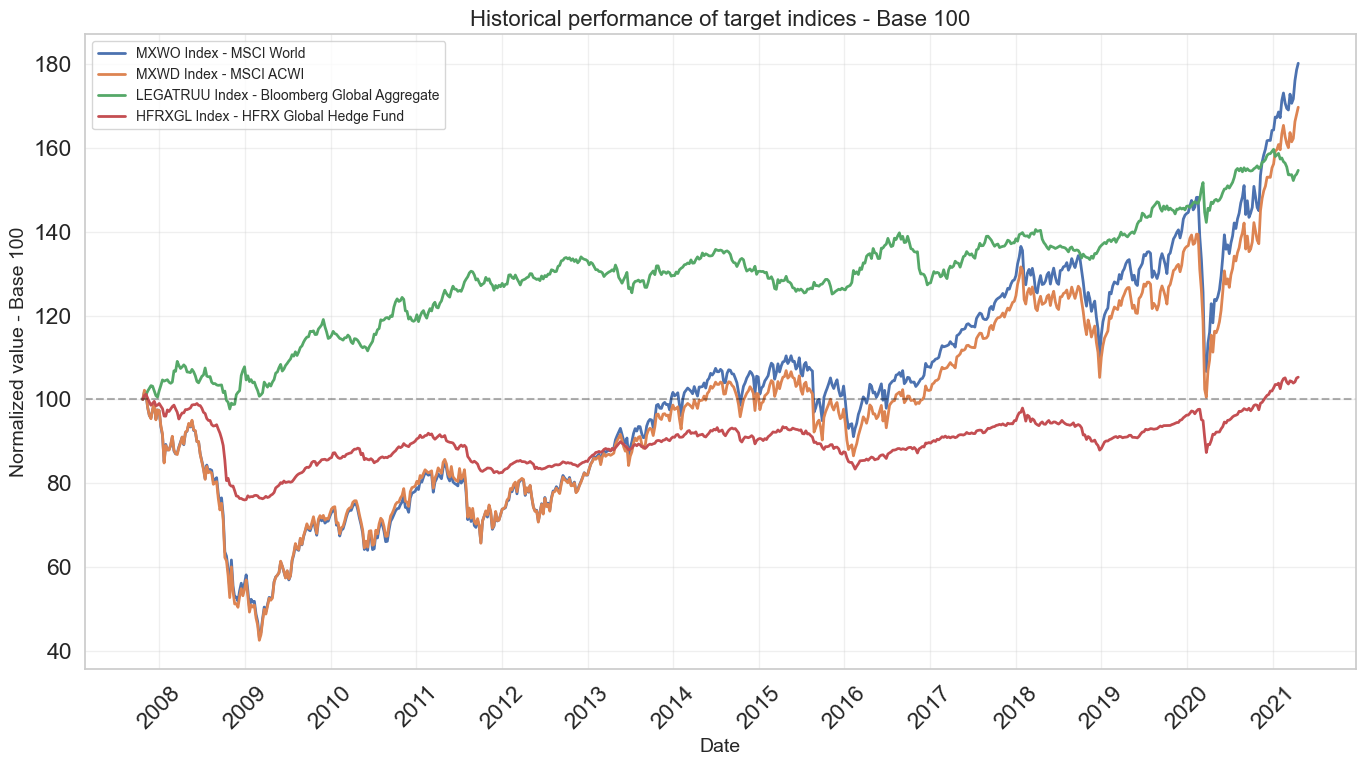

Weekly returns preview:


,MXWO Index,MXWD Index,LEGATRUU Index,HFRXGL Index
Date,,,,
2007-10-30,0.018642,0.022022,0.006646,0.009601
2007-11-06,-0.007392,-0.008860,0.004636,0.002705
2007-11-13,-0.030141,-0.032252,0.008600,-0.009587
2007-11-20,-0.019397,-0.018326,0.006223,-0.008871
2007-11-27,-0.005609,-0.008606,0.006456,-0.007624



Return statistics for target indices:


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Weekly VaR 95%,Weekly Expected Shortfall 95%,Skewness,Kurtosis
MXWO Index,5.90%,17.52%,0.34,-57.61%,-3.88%,-6.10%,-0.68,4.36
MXWD Index,5.51%,17.78%,0.31,-58.39%,-3.81%,-6.21%,-0.64,4.66
LEGATRUU Index,3.37%,5.34%,0.63,-10.41%,-1.08%,-1.62%,-0.33,4.12
HFRXGL Index,0.50%,4.78%,0.10,-24.91%,-1.06%,-1.84%,-2.30,13.70


In [ ]:

target_indices = [
    "MXWO Index",
    "MXWD Index",
    "LEGATRUU Index",
    "HFRXGL Index"
]

# Additional safety check
missing_cols = [col for col in target_indices if col not in data.columns]
if missing_cols:
    raise ValueError(f"Missing columns in data: {missing_cols}")

# Historical performance, base 100

plt.figure(figsize=(14, 8))

for idx in target_indices:
    normalized_series = data[idx] / data[idx].iloc[0] * 100
    
    label_name = variable_info.get(idx, idx)
    
    plt.plot(
        normalized_series.index,
        normalized_series,
        linewidth=2,
        label=f"{idx} - {label_name}"
    )

plt.title("Historical performance of target indices - Base 100", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Normalized value - Base 100", fontsize=14)
plt.axhline(y=100, color="black", linestyle="--", alpha=0.3)
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=10)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



# Weekly returns
returns = data[target_indices].pct_change(fill_method=None).dropna()
print("Weekly returns preview:")
display(returns.head())


# Return statistics
annual_factor = 52  # weekly data

def max_drawdown(return_series):
    cumulative = (1 + return_series).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    return drawdown.min()


# Risk tail metrics
var_95 = returns.quantile(0.05)
es_95 = returns.apply(lambda x: x[x <= x.quantile(0.05)].mean())


stats_raw = pd.DataFrame({
    "Annualized Return": returns.mean() * annual_factor,
    "Annualized Volatility": returns.std() * np.sqrt(annual_factor),
    "Sharpe Ratio": (returns.mean() * annual_factor) / (returns.std() * np.sqrt(annual_factor)),
    "Max Drawdown": returns.apply(max_drawdown),
    "Weekly VaR 95%": var_95,
    "Weekly Expected Shortfall 95%": es_95,
    "Skewness": returns.skew(),
    "Kurtosis": returns.kurtosis()
})

stats = stats_raw.copy()

percentage_cols = [
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Weekly VaR 95%",
    "Weekly Expected Shortfall 95%"
]

for col in percentage_cols:
    stats[col] = stats[col].map(lambda x: f"{x * 100:.2f}%")

stats["Sharpe Ratio"] = stats["Sharpe Ratio"].map(lambda x: f"{x:.2f}")
stats["Skewness"] = stats["Skewness"].map(lambda x: f"{x:.2f}")
stats["Kurtosis"] = stats["Kurtosis"].map(lambda x: f"{x:.2f}")

print("\nReturn statistics for target indices:")
display(stats)

## 1.1 Exploratory Data Analysis (futures)

In [5]:
# Select only futures/commodities, excluding the target indices
futures_cols = tickers[4:]

def max_drawdown(x):
    cumulative = (1 + x).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    return drawdown.min()

def fmt_pct(x):
    return f"{x:.2%}"

annual_factor = 52  
futures_returns = data[futures_cols].pct_change(fill_method=None).dropna()
var_95 = futures_returns.quantile(0.05)
es_95 = futures_returns.apply(lambda x: x[x <= x.quantile(0.05)].mean())


futures_stats = pd.DataFrame({
    "Ann. Return": futures_returns.mean() * annual_factor,
    "Ann. Volatility": futures_returns.std() * np.sqrt(annual_factor),
    "Sharpe Ratio": (
        futures_returns.mean() * annual_factor
    ) / (
        futures_returns.std() * np.sqrt(annual_factor)
    ),
    "Calmar Ratio": futures_returns.apply(
        lambda x: (x.mean() * annual_factor) / abs(max_drawdown(x))
    ),
    "Max Drawdown": futures_returns.apply(max_drawdown),
    "Weekly VaR 95%": var_95,
    "Weekly Expected Shortfall 95%": es_95,
    "Skewness": futures_returns.skew(),
    "Kurtosis": futures_returns.kurtosis(),
})

futures_stats.index = [
    f"{col} — {variable_info.get(col, col)}" for col in futures_cols
]

percentage_cols = [
    "Ann. Return",
    "Ann. Volatility",
    "Max Drawdown",
    "Weekly VaR 95%",
    "Weekly Expected Shortfall 95%"
]

for col in percentage_cols:
    futures_stats[col] = futures_stats[col].map(lambda x: f"{x * 100:.2f}%")

for col in ["Sharpe Ratio", "Calmar Ratio", "Skewness", "Kurtosis"]:
    futures_stats[col] = futures_stats[col].map(lambda x: f"{x:.2f}")

display(futures_stats)

,Ann. Return,Ann. Volatility,Sharpe Ratio,Calmar Ratio,Max Drawdown,Weekly VaR 95%,Weekly Expected Shortfall 95%,Skewness,Kurtosis
RX1 Comdty — Euro-Bund Future,3.20%,6.14%,0.52,0.31,-10.39%,-1.50%,-2.10%,-0.52,1.61
TY1 Comdty — US 10yr Note Future,1.50%,5.63%,0.27,0.12,-12.90%,-1.26%,-1.85%,-0.41,3.09
GC1 Comdty — Gold Future,7.85%,17.72%,0.44,0.18,-43.18%,-3.73%,-5.35%,0.05,3.47
CO1 Comdty — Brent Crude Future,6.51%,40.68%,0.16,0.08,-86.26%,-7.84%,-12.18%,1.07,16.38
ES1 Comdty — S&P 500 Future,8.83%,17.01%,0.52,0.16,-55.11%,-3.95%,-5.99%,-1.04,5.17
VG1 Comdty — Euro Stoxx 50 Future,1.49%,21.70%,0.07,0.03,-58.15%,-5.09%,-7.09%,-0.09,3.60
NQ1 Comdty — Nasdaq 100 Future,15.46%,19.43%,0.80,0.30,-52.00%,-4.21%,-6.51%,-0.94,3.92
LLL1 Comdty — Lead Future,0.53%,18.10%,0.03,0.01,-64.87%,-3.15%,-6.32%,-0.57,25.94
TP1 Comdty — Topix Future,4.10%,22.57%,0.18,0.07,-56.29%,-5.06%,-7.95%,-0.68,5.15
DU1 Comdty — Euro-Schatz Future,0.60%,1.13%,0.54,0.22,-2.77%,-0.22%,-0.39%,-0.24,5.20


 ## 2.0 Correlation & Distribution Analysis

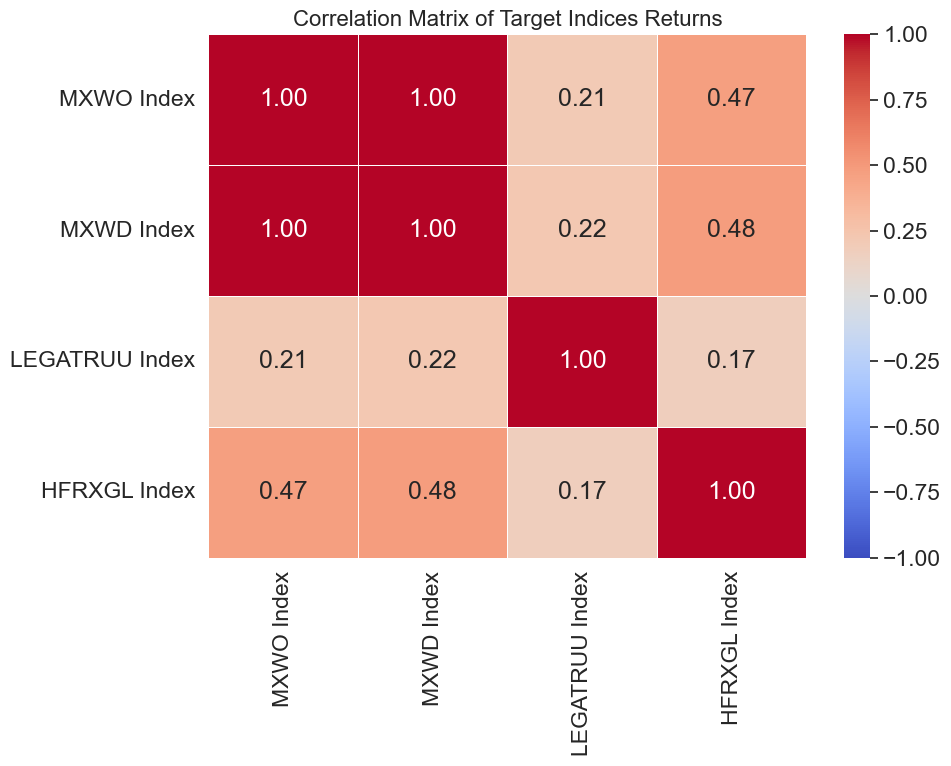

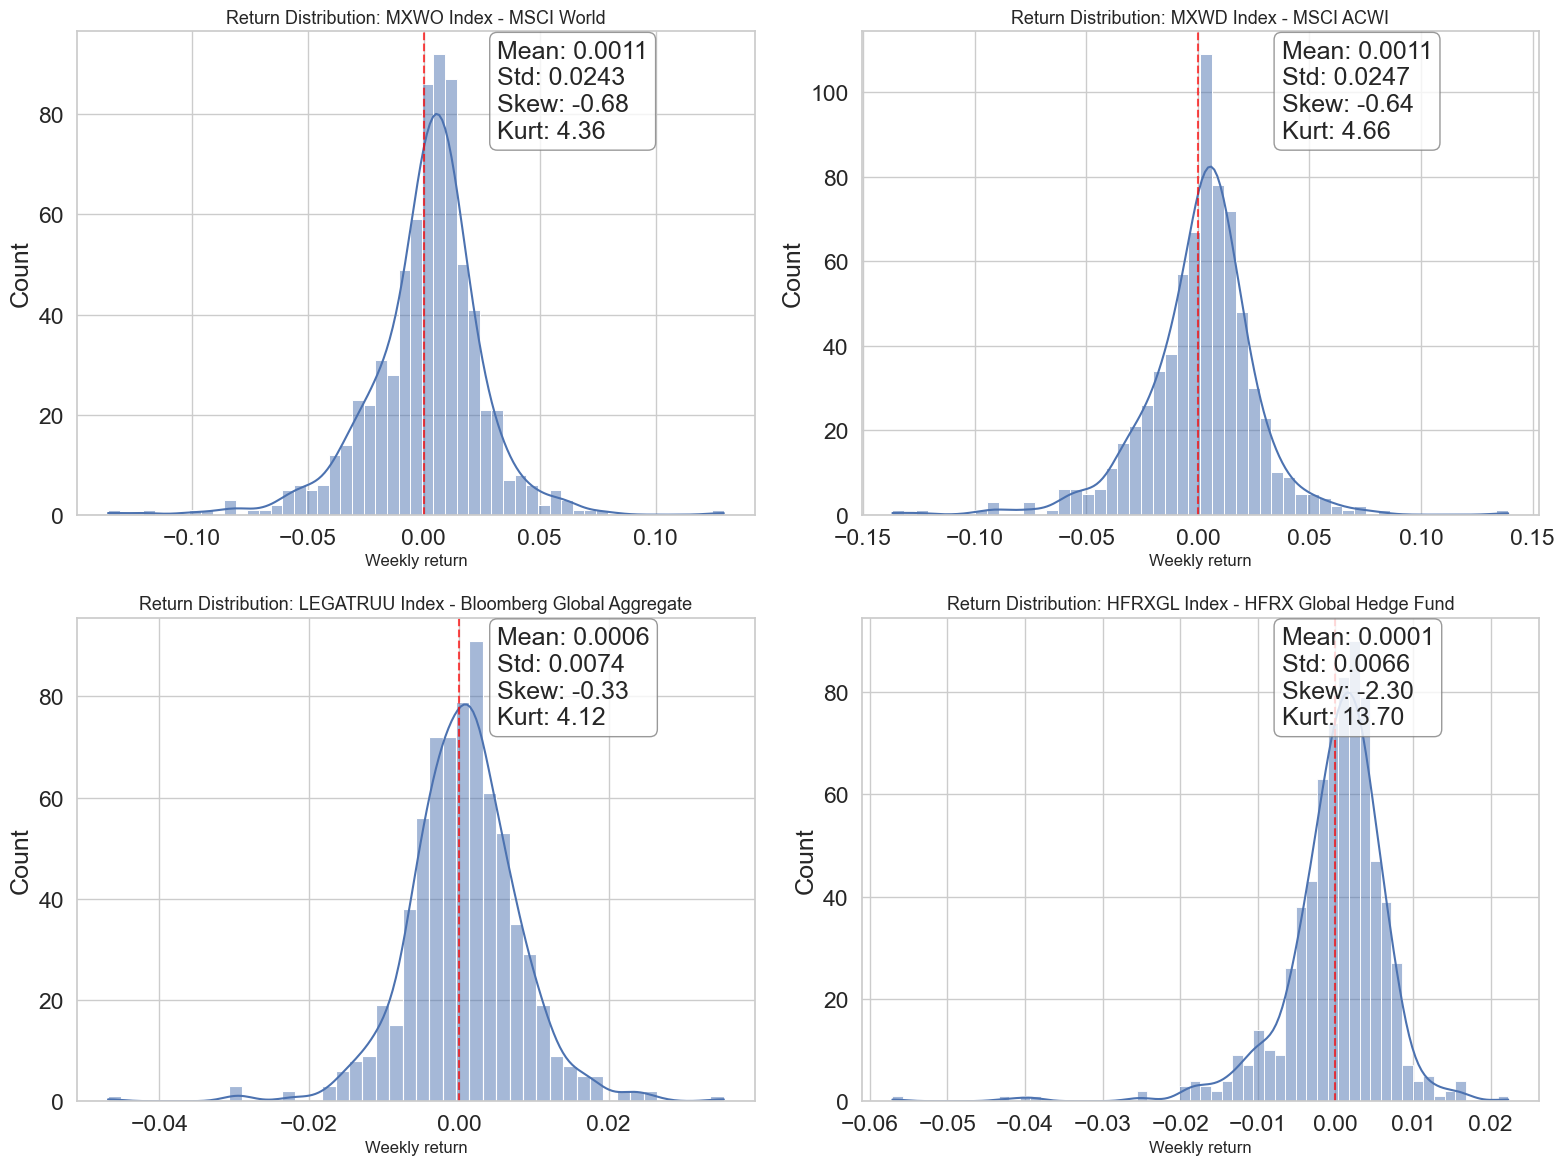

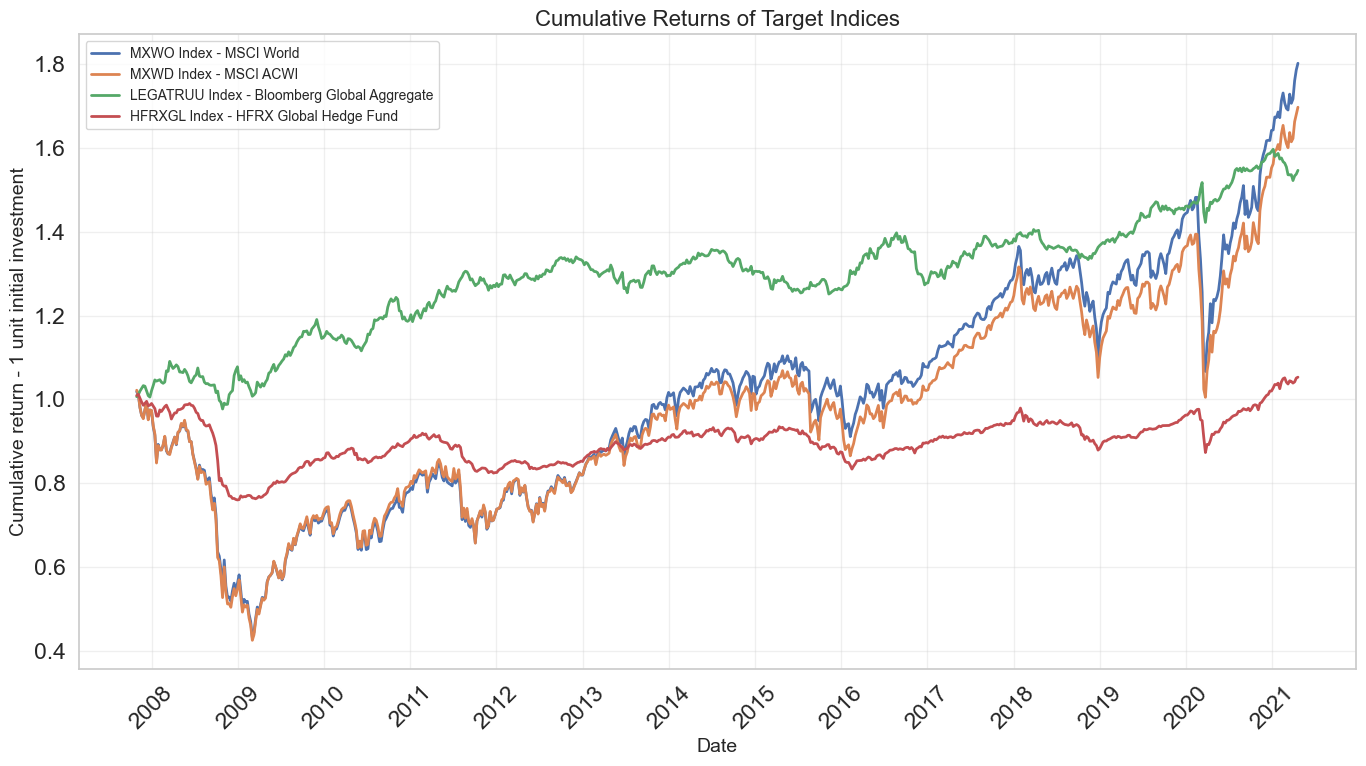

,Target,Future,Mean Rolling Corr,Std Rolling Corr,Min Rolling Corr,Max Rolling Corr
37,HFRXGL Index,ES1 Comdty,0.462028,0.127856,0.091430,0.720600
41,HFRXGL Index,TP1 Comdty,0.437688,0.155202,-0.153429,0.738477
39,HFRXGL Index,NQ1 Comdty,0.414282,0.121405,-0.019183,0.672467
38,HFRXGL Index,VG1 Comdty,0.358858,0.132637,-0.043458,0.633367
36,HFRXGL Index,CO1 Comdty,0.296087,0.131184,-0.101482,0.542470
40,HFRXGL Index,LLL1 Comdty,0.266930,0.113567,-0.030584,0.446342
33,HFRXGL Index,RX1 Comdty,-0.008140,0.183116,-0.334225,0.487150
35,HFRXGL Index,GC1 Comdty,-0.009228,0.124990,-0.405621,0.514956
42,HFRXGL Index,DU1 Comdty,-0.042456,0.187802,-0.380354,0.520588
34,HFRXGL Index,TY1 Comdty,-0.129401,0.198069,-0.514667,0.338885


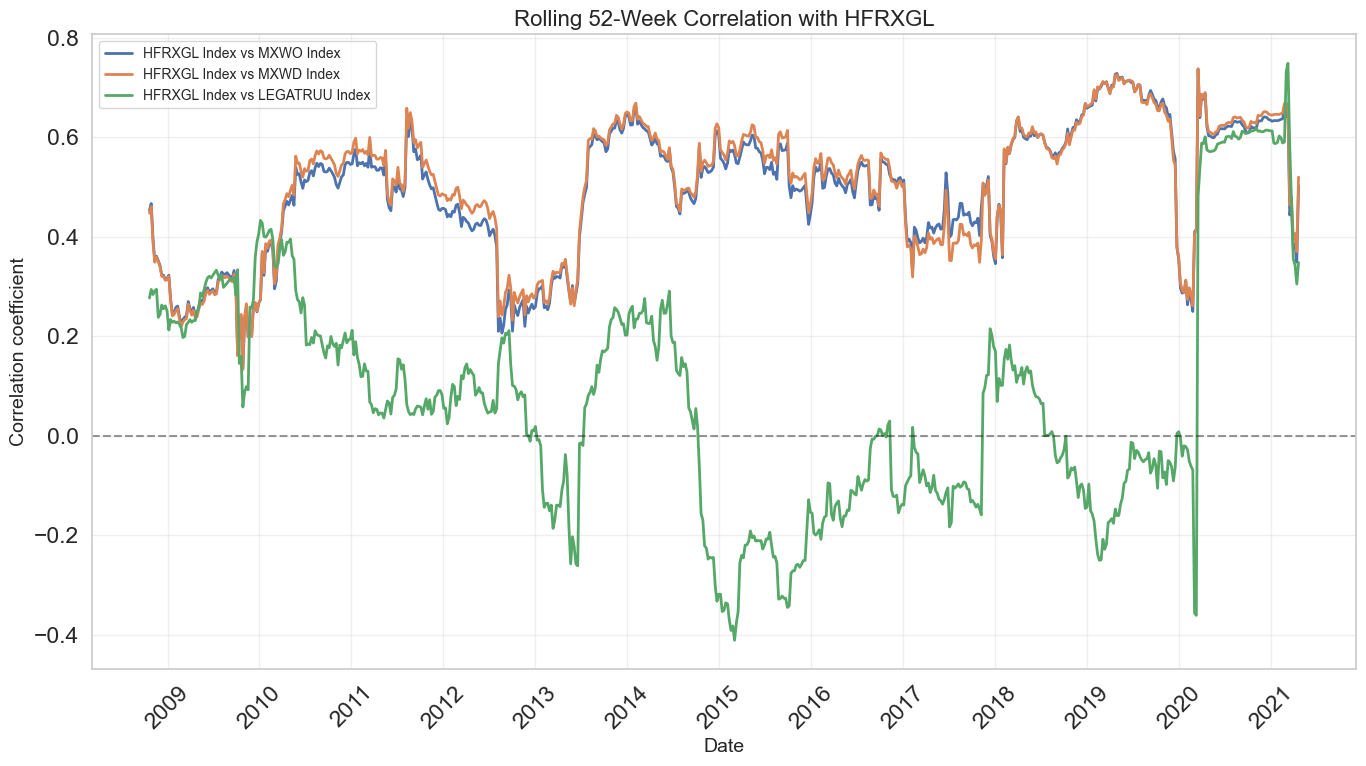

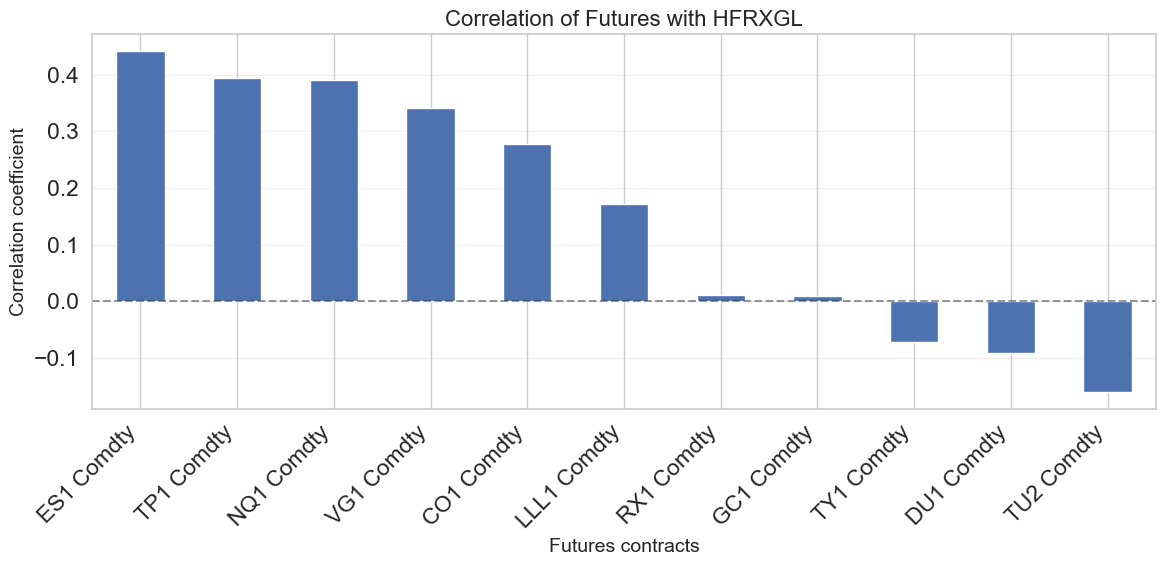

,Correlation with HFRXGL
ES1 Comdty,0.441
TP1 Comdty,0.395
NQ1 Comdty,0.391
VG1 Comdty,0.342
CO1 Comdty,0.278
LLL1 Comdty,0.172
RX1 Comdty,0.012
GC1 Comdty,0.008
TY1 Comdty,-0.073
DU1 Comdty,-0.092


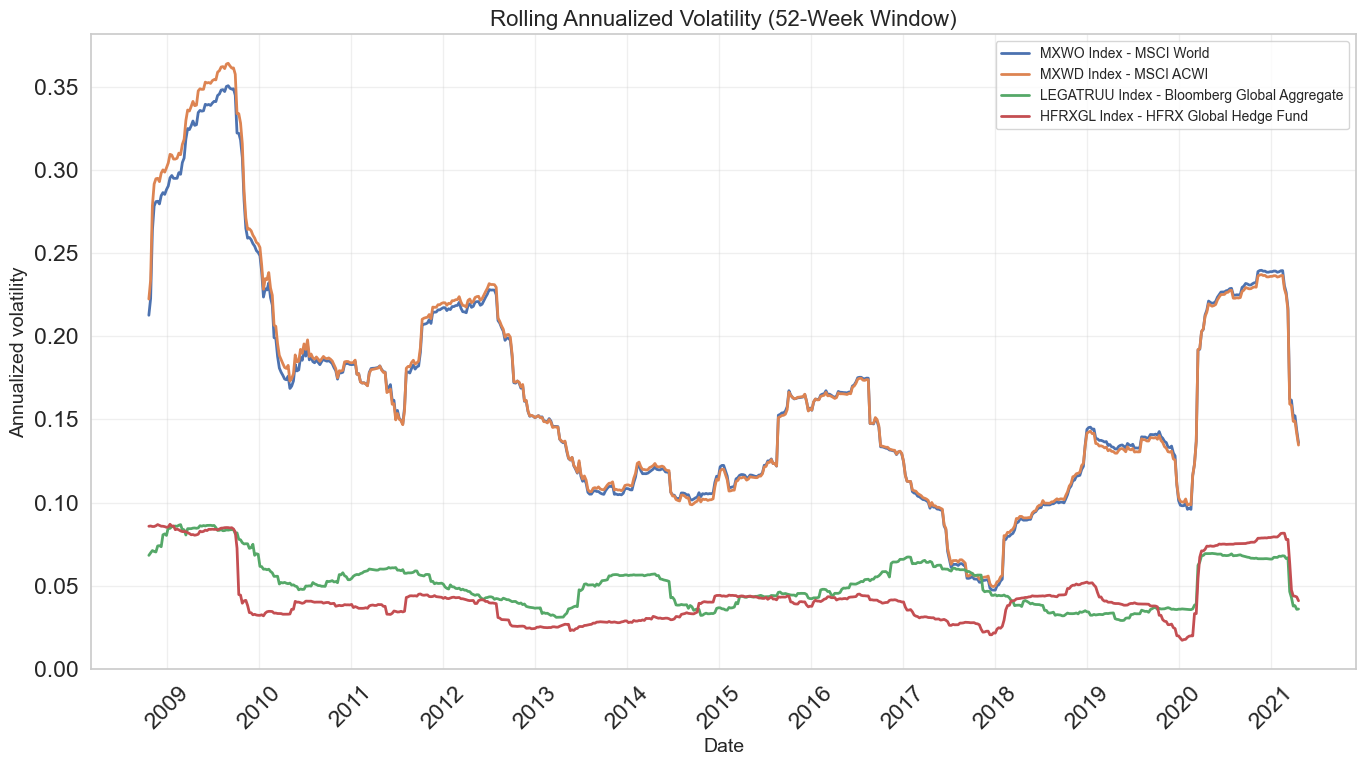

In [6]:

# Compute returns for all assets
returns_all = data.pct_change(fill_method=None).dropna()

# Target indices
target_indices = [
    "MXWO Index",
    "MXWD Index",
    "LEGATRUU Index",
    "HFRXGL Index"
]

# Futures / replicating instruments
futures_cols = tickers[4:]

# Safety checks
missing_targets = [col for col in target_indices if col not in returns_all.columns]
missing_futures = [col for col in futures_cols if col not in returns_all.columns]

if missing_targets:
    raise ValueError(f"Missing target columns: {missing_targets}")

if missing_futures:
    raise ValueError(f"Missing futures columns: {missing_futures}")

# Correlation matrix of target indices 
plt.figure(figsize=(10, 8))

correlation_matrix = returns_all[target_indices].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Target Indices Returns", fontsize=16)
plt.tight_layout()
plt.show()

#  Distribution of target returns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, idx in enumerate(target_indices):
    sns.histplot(returns_all[idx], kde=True, ax=axes[i])
    
    axes[i].set_title(
        f"Return Distribution: {idx} - {variable_info.get(idx, idx)}",
        fontsize=13
    )
    axes[i].set_xlabel("Weekly return", fontsize=12)
    axes[i].axvline(x=0, color="red", linestyle="--", alpha=0.7)

    mean = returns_all[idx].mean()
    std = returns_all[idx].std()
    skew = returns_all[idx].skew()
    kurt = returns_all[idx].kurtosis()

    axes[i].annotate(
        f"Mean: {mean:.4f}\nStd: {std:.4f}\nSkew: {skew:.2f}\nKurt: {kurt:.2f}",
        xy=(0.62, 0.78),
        xycoords="axes fraction",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
    )

plt.tight_layout()
plt.show()

# Cumulative returns of target indices
cumulative_returns = (1 + returns_all[target_indices]).cumprod()

plt.figure(figsize=(14, 8))

for idx in target_indices:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[idx],
        linewidth=2,
        label=f"{idx} - {variable_info.get(idx, idx)}"
    )

plt.title("Cumulative Returns of Target Indices", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Cumulative return - 1 unit initial investment", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=10)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Rolling correlation with HFRXGL 
rolling_window = 52
base_idx = "HFRXGL Index"

rolling_corr_summary = []

for target in target_indices:
    for future in futures_cols:
        rc = returns_all[target].rolling(rolling_window).corr(returns_all[future]).dropna()
        rolling_corr_summary.append({
            "Target": target,
            "Future": future,
            "Mean Rolling Corr": rc.mean(),
            "Std Rolling Corr": rc.std(),
            "Min Rolling Corr": rc.min(),
            "Max Rolling Corr": rc.max()
        })

rolling_corr_summary = pd.DataFrame(rolling_corr_summary)

display(
    rolling_corr_summary
    .sort_values(["Target", "Mean Rolling Corr"], ascending=[True, False])
)

plt.figure(figsize=(14, 8))

for idx in [col for col in target_indices if col != base_idx]:
    rolling_corr = returns_all[base_idx].rolling(rolling_window).corr(returns_all[idx])
    
    plt.plot(
        rolling_corr.index,
        rolling_corr,
        linewidth=2,
        label=f"{base_idx} vs {idx}"
    )

plt.title(f"Rolling {rolling_window}-Week Correlation with HFRXGL", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Correlation coefficient", fontsize=14)
plt.axhline(y=0, color="black", linestyle="--", alpha=0.4)
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=10)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Correlation between HFRXGL and futures
corr_with_hfrx = returns_all[futures_cols].corrwith(returns_all[base_idx]).sort_values(ascending=False)

plt.figure(figsize=(12, 6))

corr_with_hfrx.plot(kind="bar")

plt.title("Correlation of Futures with HFRXGL", fontsize=16)
plt.xlabel("Futures contracts", fontsize=14)
plt.ylabel("Correlation coefficient", fontsize=14)
plt.axhline(y=0, color="black", linestyle="--", alpha=0.4)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

display(
    corr_with_hfrx.rename("Correlation with HFRXGL").to_frame().round(3)
)

# Rolling volatility of target indices
rolling_volatility = returns_all[target_indices].rolling(rolling_window).std() * np.sqrt(52)

plt.figure(figsize=(14, 8))

for idx in target_indices:
    plt.plot(
        rolling_volatility.index,
        rolling_volatility[idx],
        linewidth=2,
        label=f"{idx} - {variable_info.get(idx, idx)}"
    )

plt.title(f"Rolling Annualized Volatility ({rolling_window}-Week Window)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Annualized volatility", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=10)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.0 Target construction and initial analysis of futures

### 3.1 Correlation between target and futures

Main target weights sum to 1.
Synthetic target statistics:


,Value
Metric,
Annualized Return,1.68%
Annualized Volatility,5.42%
Sharpe Ratio,0.31
Max Drawdown,-27.31%
Weekly VaR 95%,-1.16%
Weekly Expected Shortfall 95%,-2.00%
Skewness,-1.80
Kurtosis,9.58


Target vs underlying components:


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Weekly VaR 95%,Weekly Expected Shortfall 95%,Skewness,Kurtosis
HFRXGL Index,0.50%,4.78%,0.10,-24.91%,-1.06%,-1.84%,-2.30,13.70
MXWD Index,5.51%,17.78%,0.31,-58.39%,-3.81%,-6.21%,-0.64,4.66
LEGATRUU Index,3.37%,5.34%,0.63,-10.41%,-1.08%,-1.62%,-0.33,4.12
Synthetic Target,1.68%,5.42%,0.31,-27.31%,-1.16%,-2.00%,-1.80,9.58


Synthetic target portfolio composition:


,Component,Description,Weight
0,HFRXGL Index,HFRX Global Hedge Fund,70%
1,MXWD Index,MSCI ACWI,15%
2,LEGATRUU Index,Bloomberg Global Aggregate,15%


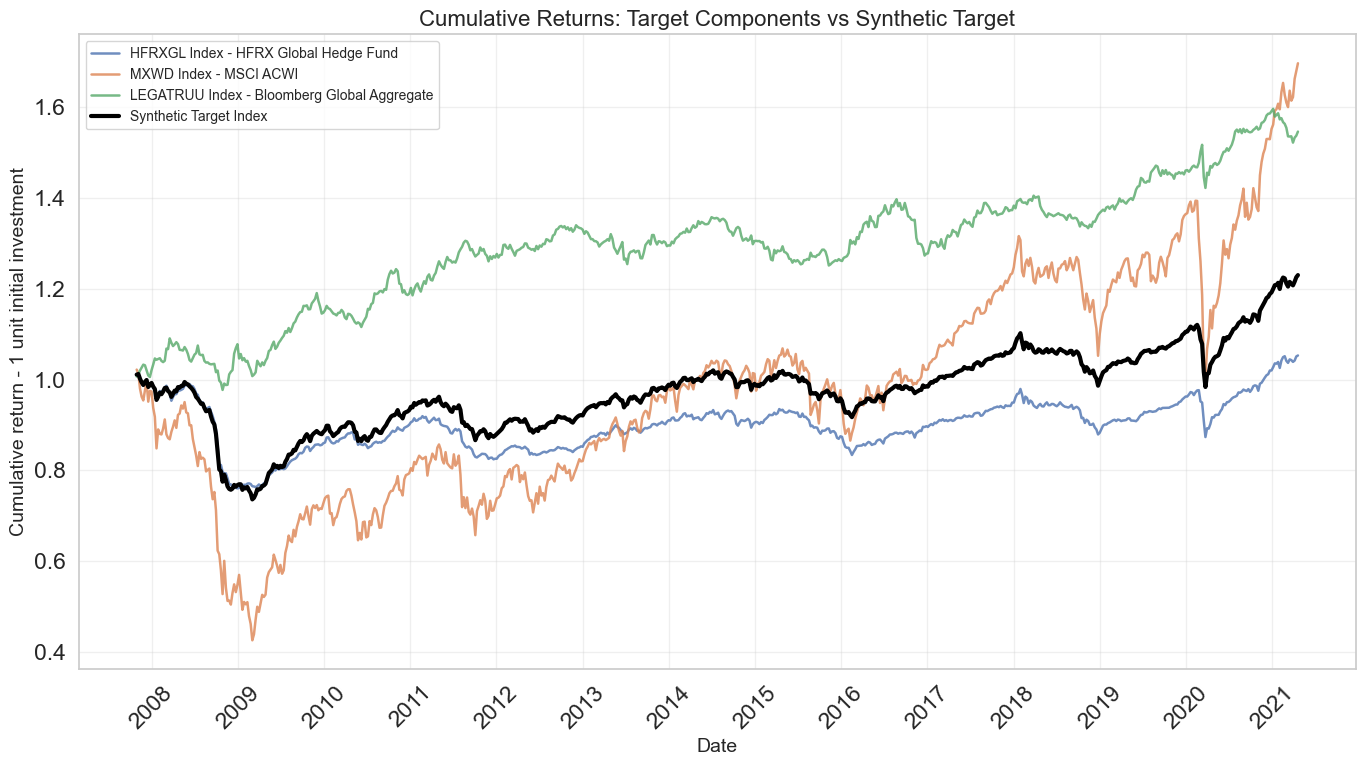

Correlation between synthetic target and futures:


,Correlation with Target
ES1 Comdty,0.744
NQ1 Comdty,0.663
VG1 Comdty,0.637
TP1 Comdty,0.567
LLL1 Comdty,0.425
CO1 Comdty,0.416
DU1 Comdty,-0.218
GC1 Comdty,0.164
TU2 Comdty,-0.163
TY1 Comdty,-0.109


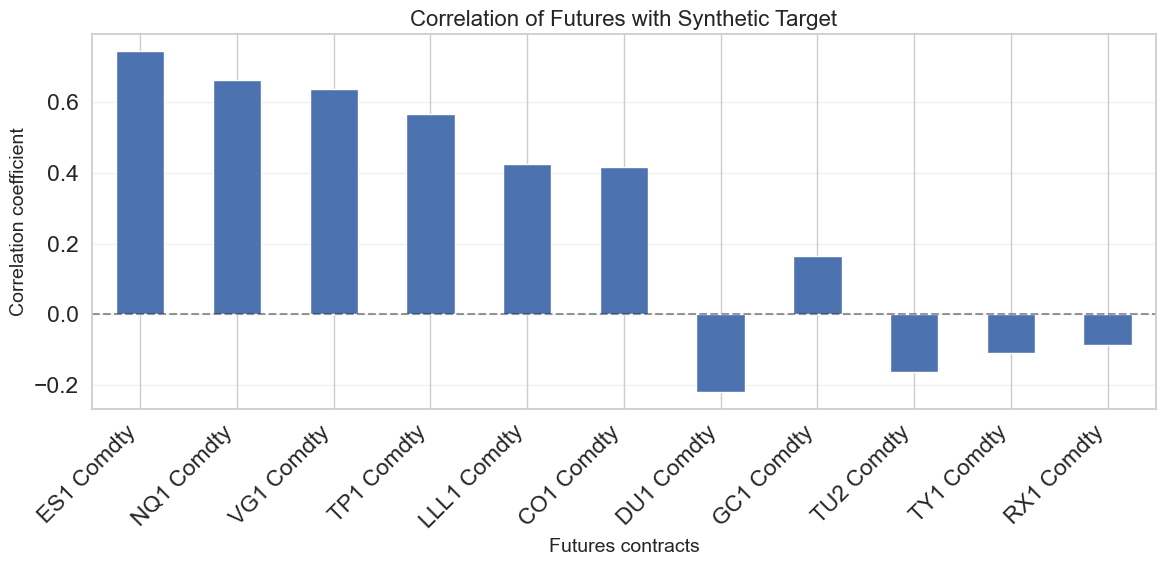

In [7]:
# Target construction and preliminary futures analysis
import warnings
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message="invalid value encountered in divide"
)

# MODIFIED TARGET:
# We keep MXWD as global equity exposure and combine it with hedge funds and bonds.
target_components = {
    "HFRXGL Index": 0.7,    # Hedge Fund / alternative exposure
    "MXWD Index": 0.15,      # Global equity exposure
    "LEGATRUU Index": 0.15   # Global bond exposure
}

if not np.isclose(sum(target_components.values()), 1.0):
    raise ValueError("Target weights must sum to 1.")

print("Main target weights sum to 1.")

# Futures used as replicating instruments
futures_contracts = [
    "RX1 Comdty", "TY1 Comdty", "GC1 Comdty", "CO1 Comdty",
    "ES1 Comdty", "VG1 Comdty", "NQ1 Comdty", "LLL1 Comdty",
    "TP1 Comdty", "DU1 Comdty", "TU2 Comdty"
]

# Safety checks
missing_target_components = [col for col in target_components.keys() if col not in data.columns]
missing_futures = [col for col in futures_contracts if col not in data.columns]

if missing_target_components:
    raise ValueError(f"Missing target component columns: {missing_target_components}")

if missing_futures:
    raise ValueError(f"Missing futures columns: {missing_futures}")

# Compute weekly returns
component_returns = data[list(target_components.keys())].pct_change(fill_method=None).dropna()
futures_returns = data[futures_contracts].pct_change(fill_method=None).dropna()

# Create the synthetic target index returns 
target_returns = pd.Series(0, index=component_returns.index, dtype=float)

for component, weight in target_components.items():
    target_returns += component_returns[component] * weight

target_returns.name = "Target_Index"

# Align target and futures on common dates 
common_dates = target_returns.index.intersection(futures_returns.index)

target_returns_aligned = target_returns.loc[common_dates]



# Summary statistics for the synthetic target
target_var_95 = target_returns_aligned.quantile(0.05)
target_es_95 = target_returns_aligned[
    target_returns_aligned <= target_var_95
].mean()

target_stats_raw = {
    "Annualized Return": target_returns_aligned.mean() * 52,
    "Annualized Volatility": target_returns_aligned.std() * np.sqrt(52),
    "Sharpe Ratio": (
        target_returns_aligned.mean() * 52
    ) / (
        target_returns_aligned.std() * np.sqrt(52)
    ),
    "Max Drawdown": max_drawdown(target_returns_aligned),
    "Weekly VaR 95%": target_var_95,
    "Weekly Expected Shortfall 95%": target_es_95,
    "Skewness": target_returns_aligned.skew(),
    "Kurtosis": target_returns_aligned.kurtosis()
}

percentage_metrics = [
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Weekly VaR 95%",
    "Weekly Expected Shortfall 95%"
]

formatted_values = {}

for metric, value in target_stats_raw.items():
    if metric in percentage_metrics:
        formatted_values[metric] = f"{value * 100:.2f}%"
    else:
        formatted_values[metric] = f"{value:.2f}"

target_stats_display = pd.DataFrame.from_dict(
    formatted_values,
    orient="index",
    columns=["Value"]
)

target_stats_display.index.name = "Metric"

print("Synthetic target statistics:")
display(target_stats_display)


# Target vs components comparison
target_and_components = component_returns.loc[common_dates].copy()
target_and_components["Synthetic Target"] = target_returns_aligned

comparison_raw = pd.DataFrame({
    "Ann. Return": target_and_components.mean() * 52,
    "Ann. Volatility": target_and_components.std() * np.sqrt(52),
    "Sharpe Ratio": (
        target_and_components.mean() * 52
    ) / (
        target_and_components.std() * np.sqrt(52)
    ),
    "Max Drawdown": target_and_components.apply(max_drawdown),
    "Weekly VaR 95%": target_and_components.quantile(0.05),
    "Weekly Expected Shortfall 95%": target_and_components.apply(
        lambda x: x[x <= x.quantile(0.05)].mean()
    ),
    "Skewness": target_and_components.skew(),
    "Kurtosis": target_and_components.kurtosis()
})

comparison_display = comparison_raw.copy()

percentage_cols = [
    "Ann. Return",
    "Ann. Volatility",
    "Max Drawdown",
    "Weekly VaR 95%",
    "Weekly Expected Shortfall 95%"
]

for col in percentage_cols:
    comparison_display[col] = comparison_display[col].map(lambda x: f"{x * 100:.2f}%")

for col in ["Sharpe Ratio", "Skewness", "Kurtosis"]:
    comparison_display[col] = comparison_display[col].map(lambda x: f"{x:.2f}")

print("Target vs underlying components:")
display(comparison_display)



futures_returns = futures_returns.loc[common_dates]

# Display target composition 
target_weights = pd.DataFrame({
    "Component": list(target_components.keys()),
    "Description": [variable_info.get(k, k) for k in target_components.keys()],
    "Weight": list(target_components.values())
})

target_weights["Weight"] = target_weights["Weight"].map(lambda x: f"{x:.0%}")

print("Synthetic target portfolio composition:")
display(target_weights)

# Plot cumulative performance of target components and synthetic target 
target_cumulative = (1 + target_returns_aligned).cumprod()
components_cumulative = (1 + component_returns.loc[common_dates]).cumprod()

plt.figure(figsize=(14, 8))

for col in components_cumulative.columns:
    plt.plot(
        components_cumulative.index,
        components_cumulative[col],
        linewidth=1.8,
        alpha=0.8,
        label=f"{col} - {variable_info.get(col, col)}"
    )

plt.plot(
    target_cumulative.index,
    target_cumulative,
    linewidth=3,
    color="black",
    label="Synthetic Target Index"
)

plt.title("Cumulative Returns: Target Components vs Synthetic Target", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Cumulative return - 1 unit initial investment", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=10)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Correlation between target and futures 
correlations = pd.DataFrame(index=futures_contracts)

correlations["Correlation with Target"] = [
    target_returns_aligned.corr(futures_returns[contract])
    for contract in futures_contracts
]

correlations["Abs Correlation"] = correlations["Correlation with Target"].abs()
correlations = correlations.sort_values("Abs Correlation", ascending=False)

print("Correlation between synthetic target and futures:")
display(correlations[["Correlation with Target"]].round(3))

# Plot correlations
plt.figure(figsize=(12, 6))

correlations["Correlation with Target"].plot(kind="bar")

plt.title("Correlation of Futures with Synthetic Target", fontsize=16)
plt.xlabel("Futures contracts", fontsize=14)
plt.ylabel("Correlation coefficient", fontsize=14)
plt.axhline(y=0, color="black", linestyle="--", alpha=0.4)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


### 3.2 Descriptive statistics and selection of the top features

In [8]:

# Descriptive statistics: target + futures 
combined_returns = pd.concat(
    [target_returns_aligned, futures_returns],
    axis=1
)

desc_stats = combined_returns.describe().T
desc_stats["Skewness"] = combined_returns.skew()
desc_stats["Kurtosis"] = combined_returns.kurtosis()

print("Descriptive statistics for target and futures:")
display(desc_stats.round(4))

# Select top futures by absolute correlation
top_futures = correlations.index[:3].tolist()

print("Top 3 futures by absolute correlation with the target:")
for contract in top_futures:
    print(
        f"{contract} - {variable_info.get(contract, contract)}: "
        f"{correlations.loc[contract, 'Correlation with Target']:.3f}"
    )



Descriptive statistics for target and futures:


,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis
Target_Index,704.0,0.0003,0.0075,-0.0573,-0.0031,0.0012,0.0048,0.0285,-1.7970,9.5808
RX1 Comdty,704.0,0.0006,0.0085,-0.0319,-0.0039,0.0011,0.0055,0.0279,-0.5185,1.6077
TY1 Comdty,704.0,0.0003,0.0078,-0.0427,-0.0040,0.0007,0.0045,0.0337,-0.4060,3.0899
GC1 Comdty,704.0,0.0015,0.0246,-0.1257,-0.0125,0.0022,0.0155,0.1400,0.0518,3.4661
CO1 Comdty,704.0,0.0013,0.0564,-0.3470,-0.0256,0.0030,0.0282,0.5137,1.0683,16.3813
ES1 Comdty,704.0,0.0017,0.0236,-0.1396,-0.0072,0.0038,0.0141,0.0876,-1.0383,5.1677
VG1 Comdty,704.0,0.0003,0.0301,-0.1359,-0.0145,0.0021,0.0170,0.1836,-0.0889,3.6021
NQ1 Comdty,704.0,0.0030,0.0269,-0.1670,-0.0103,0.0064,0.0182,0.0849,-0.9428,3.9232
LLL1 Comdty,704.0,0.0001,0.0251,-0.2422,0.0000,0.0000,0.0000,0.2065,-0.5734,25.9433
TP1 Comdty,704.0,0.0008,0.0313,-0.1810,-0.0146,0.0028,0.0181,0.1531,-0.6826,5.1451


Top 3 futures by absolute correlation with the target:
ES1 Comdty - S&P 500 Future: 0.744
NQ1 Comdty - Nasdaq 100 Future: 0.663
VG1 Comdty - Euro Stoxx 50 Future: 0.637


### 3.3 QQ plot e Scatter plot 

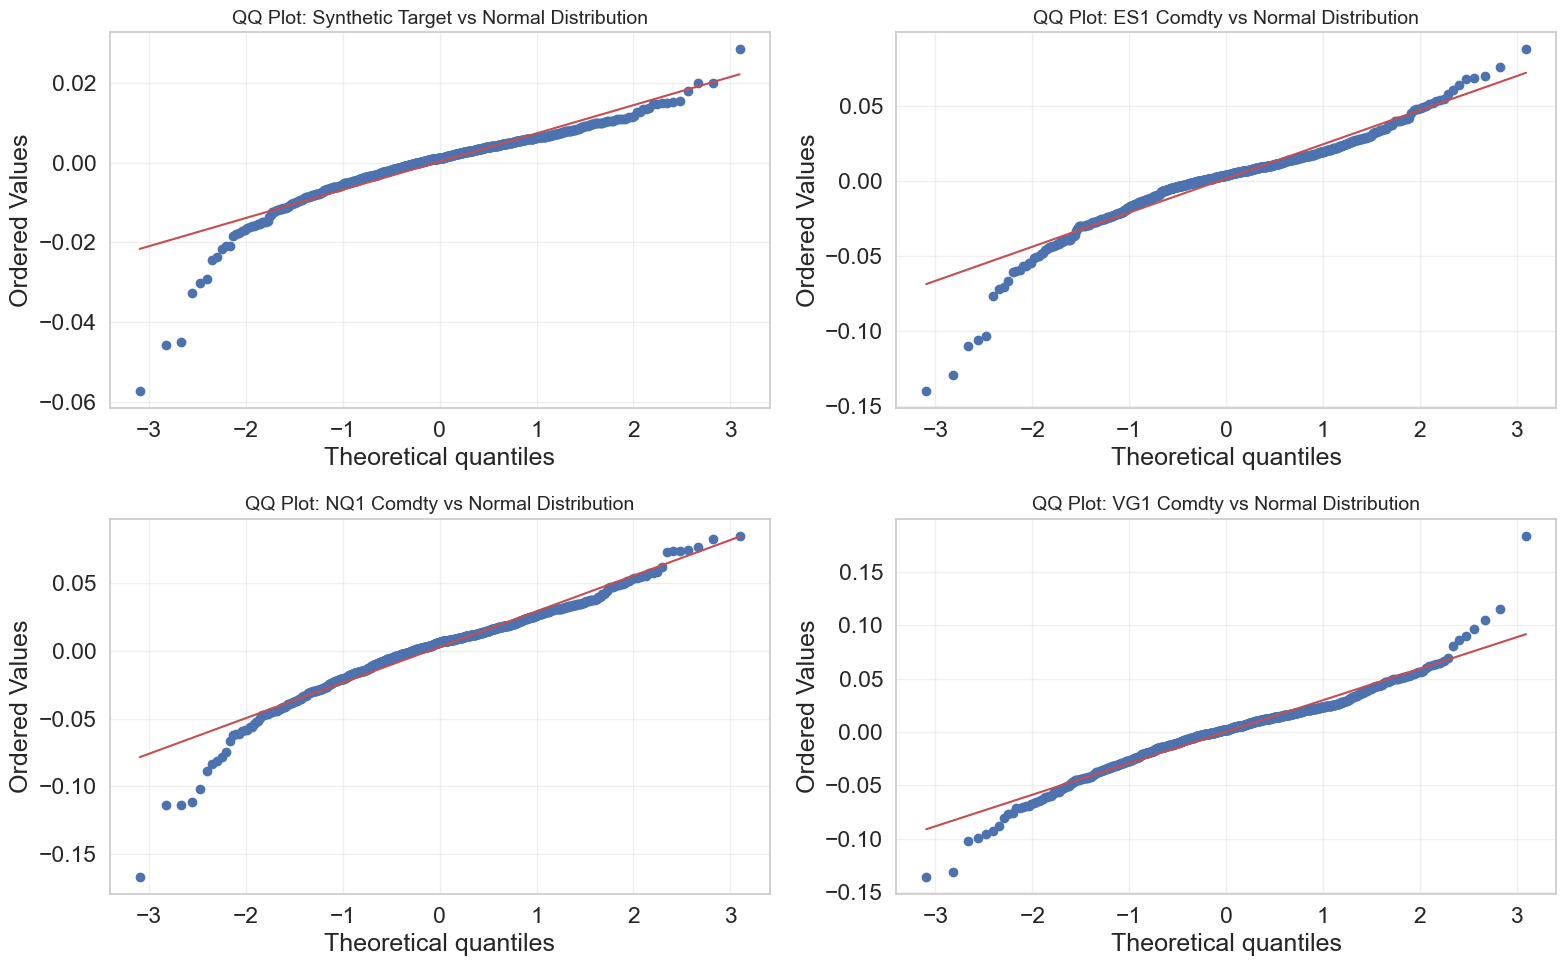

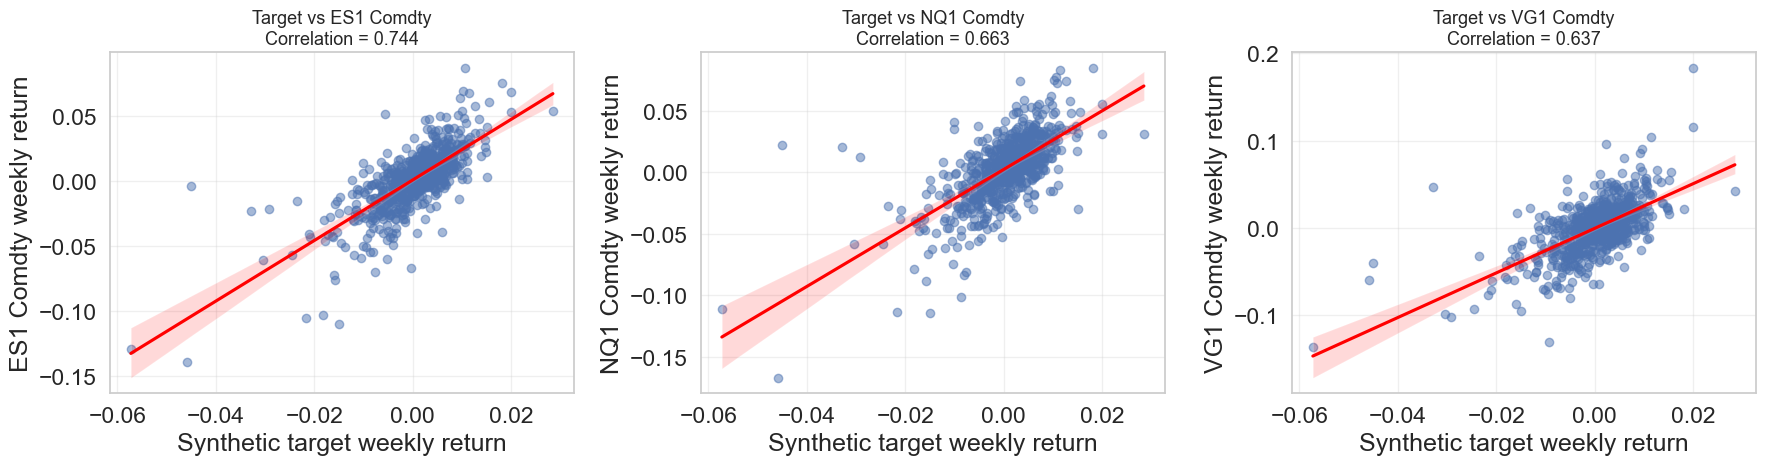

In [9]:
# QQ plots: target and top futures 
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
stats.probplot(target_returns_aligned.dropna(), dist="norm", plot=plt)
plt.title("QQ Plot: Synthetic Target vs Normal Distribution", fontsize=14)
plt.grid(True, alpha=0.3)

for i, contract in enumerate(top_futures):
    plt.subplot(2, 2, i + 2)
    stats.probplot(futures_returns[contract].dropna(), dist="norm", plot=plt)
    plt.title(f"QQ Plot: {contract} vs Normal Distribution", fontsize=14)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Scatter plots: target vs top futures 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, contract in enumerate(top_futures):
    sns.regplot(
        x=target_returns_aligned,
        y=futures_returns[contract],
        ax=axes[i],
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"}
    )

    corr_value = target_returns_aligned.corr(futures_returns[contract])

    axes[i].set_title(
        f"Target vs {contract}\nCorrelation = {corr_value:.3f}",
        fontsize=13
    )
    axes[i].set_xlabel("Synthetic target weekly return")
    axes[i].set_ylabel(f"{contract} weekly return")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.0 Autocorrelation Analysis


### 4.1 ACF and PACF

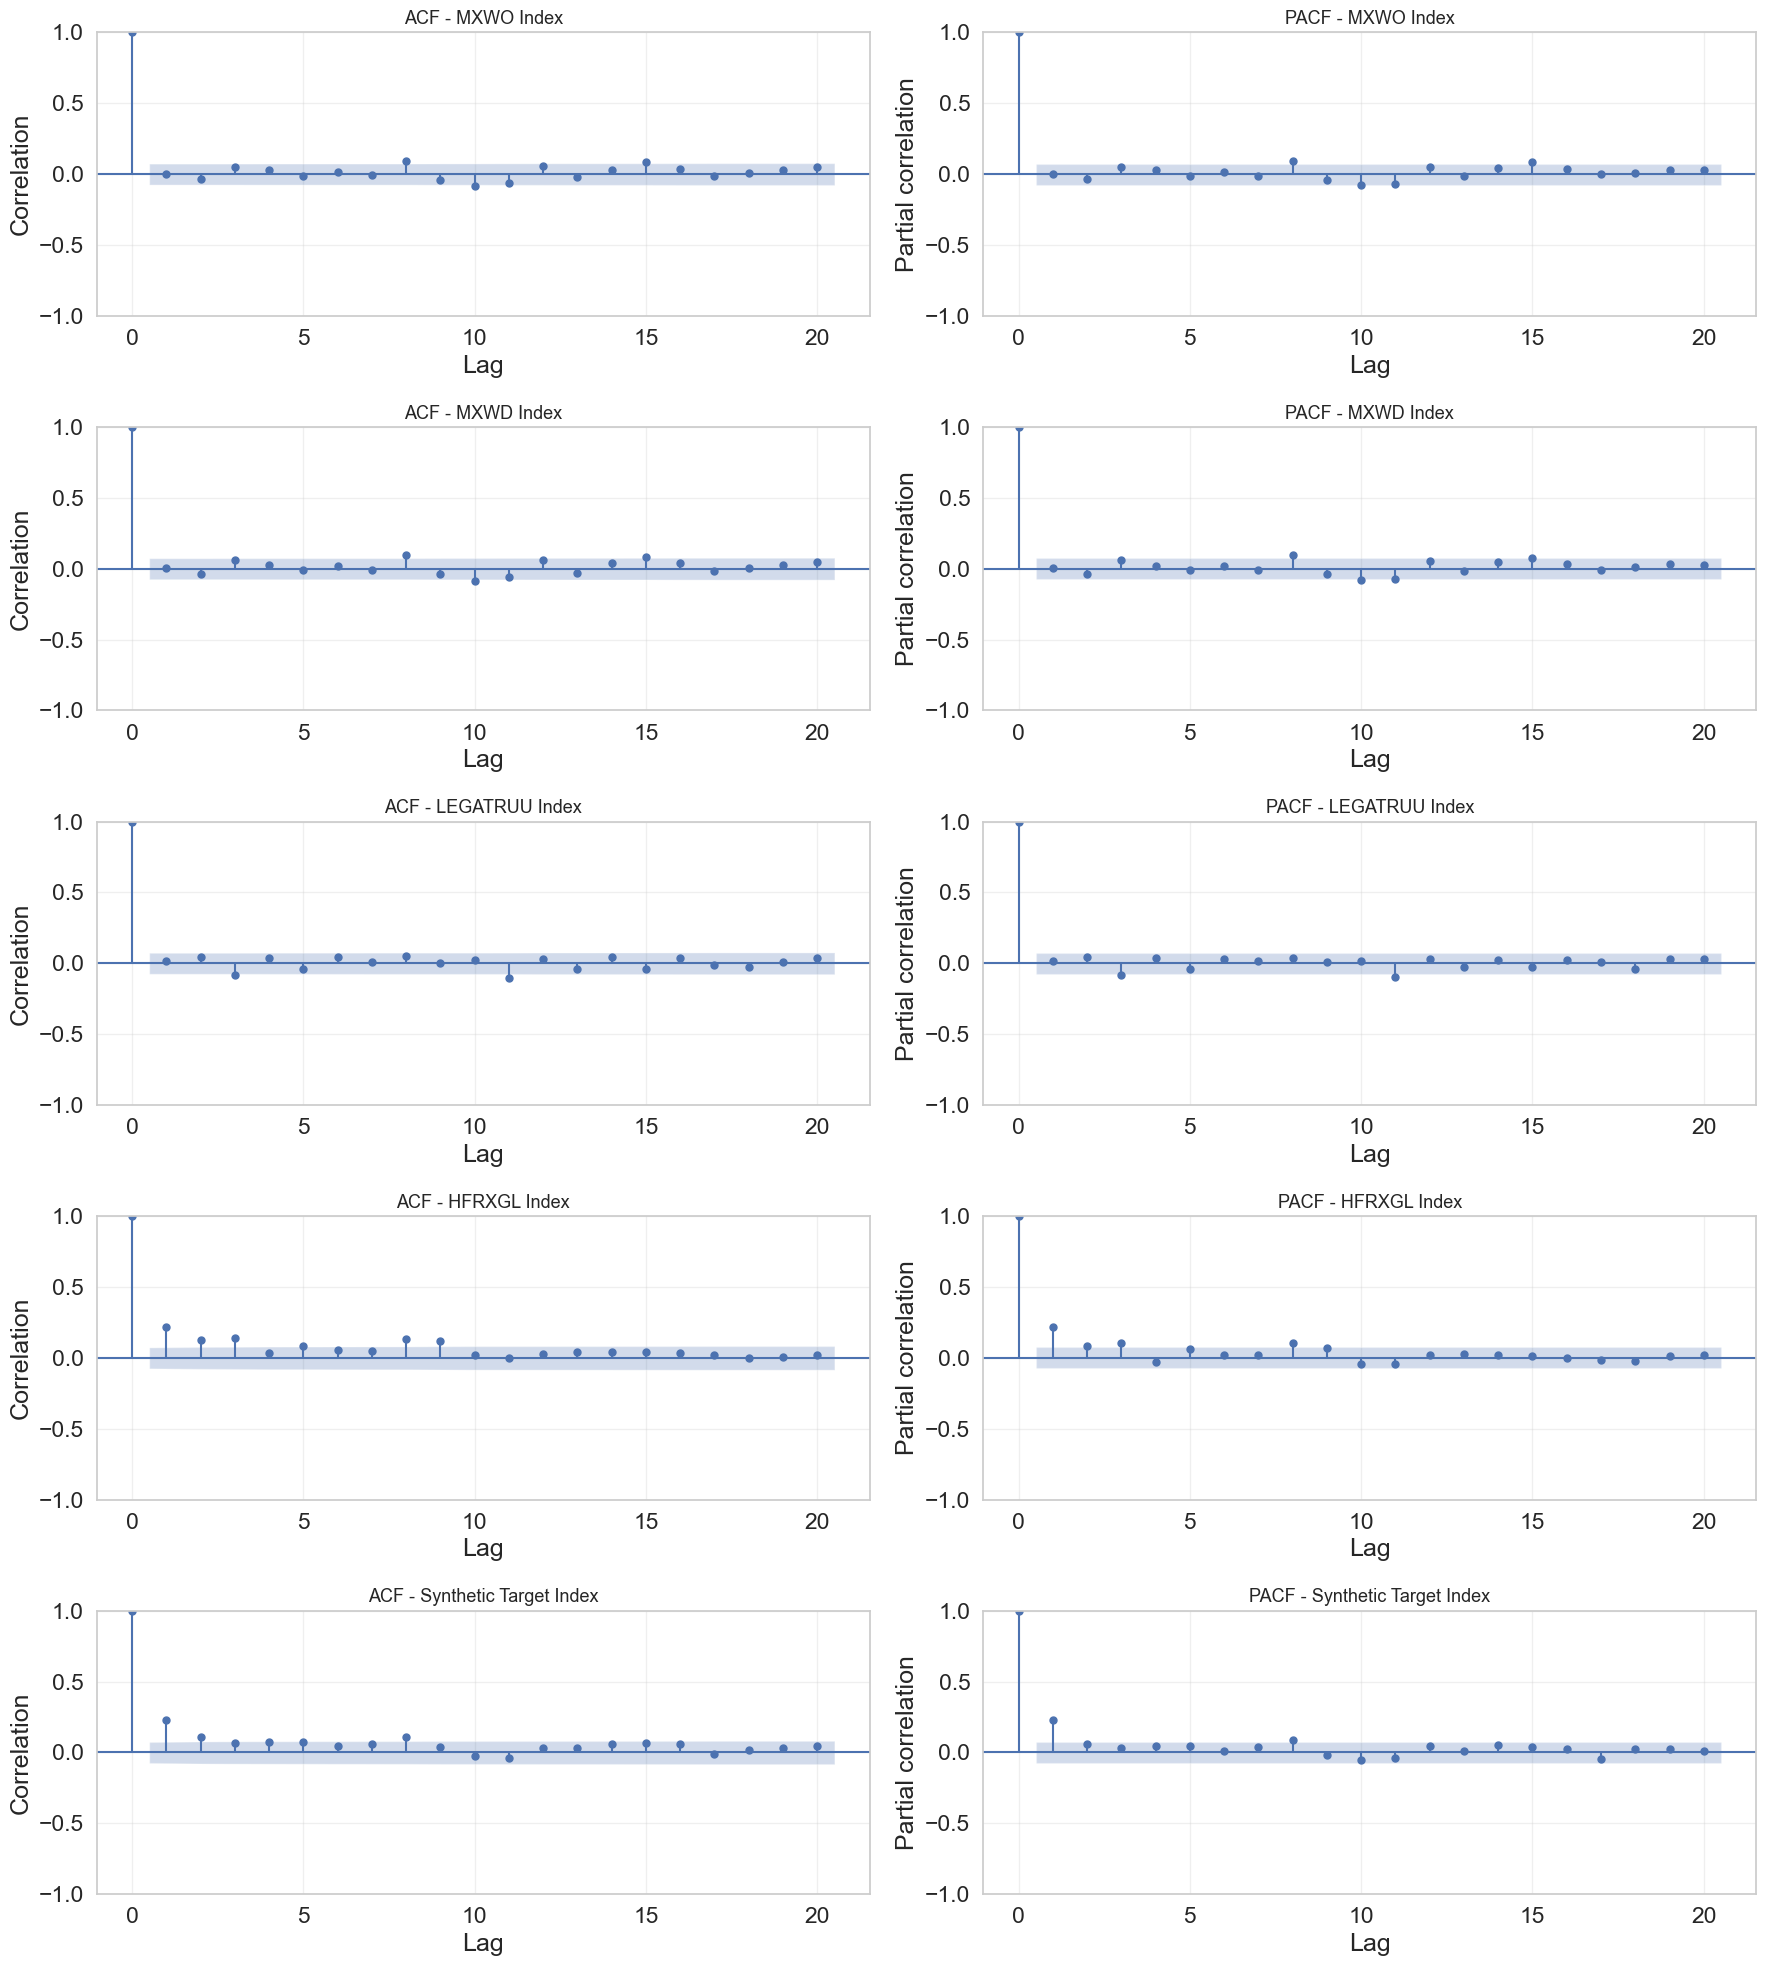

In [10]:
# Autocorrelation Analysis

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Maximum number of lags to analyze
max_lags = 20

# Build a return dataset including target indices and the Synthetic Target Index
returns_autocorr = returns_all[target_indices].copy()

# Add Synthetic Target Index if already created in the previous section
returns_autocorr["Synthetic Target Index"] = target_returns_aligned

# Drop rows with missing values after alignment
returns_autocorr = returns_autocorr.dropna()

# Series to analyze
autocorr_series = returns_autocorr.columns.tolist()

# ACF and PACF plots 
fig, axes = plt.subplots(
    len(autocorr_series),
    2,
    figsize=(18, 4 * len(autocorr_series))
)

for i, idx in enumerate(autocorr_series):
    
    series_data = returns_autocorr[idx].dropna()

    # ACF: correlation between current returns and past returns
    plot_acf(
        series_data,
        lags=max_lags,
        ax=axes[i, 0],
        alpha=0.05
    )
    axes[i, 0].set_title(f"ACF - {idx}", fontsize=13)
    axes[i, 0].set_xlabel("Lag")
    axes[i, 0].set_ylabel("Correlation")
    axes[i, 0].grid(True, alpha=0.3)

    # PACF: direct correlation with each lag
    plot_pacf(
        series_data,
        lags=max_lags,
        ax=axes[i, 1],
        alpha=0.05,
        method="ywm"
    )
    axes[i, 1].set_title(f"PACF - {idx}", fontsize=13)
    axes[i, 1].set_xlabel("Lag")
    axes[i, 1].set_ylabel("Partial correlation")
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### 4.2 Ljung-Box test

In [11]:
# Ljung-Box test 
ljung_box_results = []

for idx in autocorr_series:
    
    series_data = returns_autocorr[idx].dropna()
    
    lb_test = acorr_ljungbox(
        series_data,
        lags=[5, 10, 15, 20],
        return_df=True
    )
    
    for lag in lb_test.index:
        ljung_box_results.append({
            "Series": idx,
            "Lag": lag,
            "Ljung-Box statistic": lb_test.loc[lag, "lb_stat"],
            "p-value": lb_test.loc[lag, "lb_pvalue"]
        })

ljung_box_results = pd.DataFrame(ljung_box_results)

print("Ljung-Box test for autocorrelation")
print("H0: no autocorrelation")
display(ljung_box_results.round(4))

Ljung-Box test for autocorrelation
H0: no autocorrelation


,Series,Lag,Ljung-Box statistic,p-value
0,MXWO Index,5,3.7194,0.5905
1,MXWO Index,10,16.3144,0.0910
2,MXWO Index,15,27.3792,0.0258
3,MXWO Index,20,31.2372,0.0521
4,MXWD Index,5,4.0704,0.5393
5,MXWD Index,10,17.4323,0.0653
6,MXWD Index,15,28.4624,0.0188
7,MXWD Index,20,32.0118,0.0432
8,LEGATRUU Index,5,8.3823,0.1364
9,LEGATRUU Index,10,11.6799,0.3071


## 5.0 Volatility Clustering Analysis

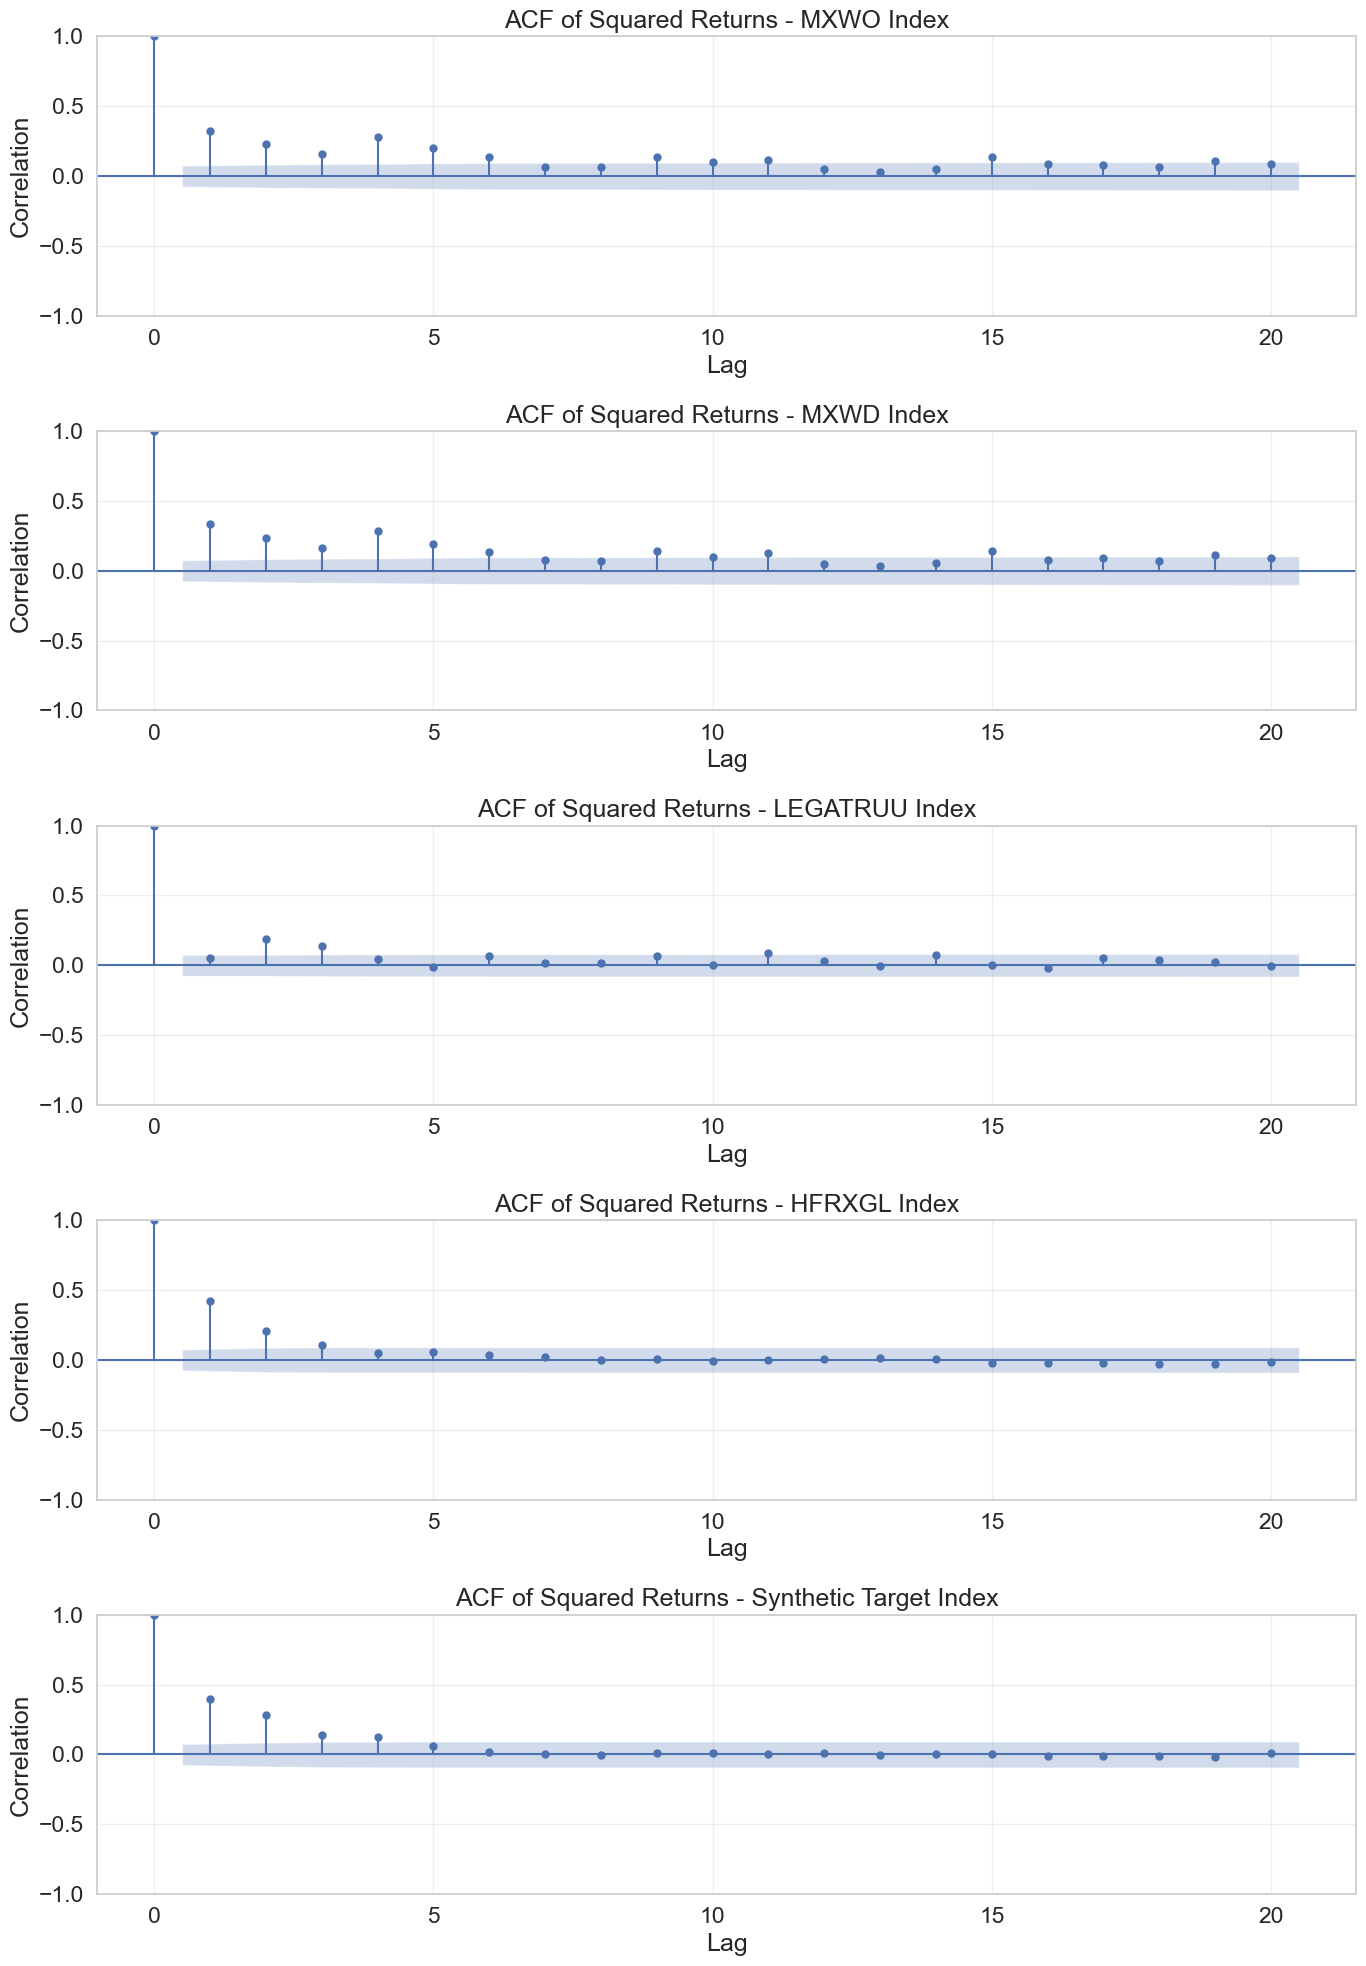

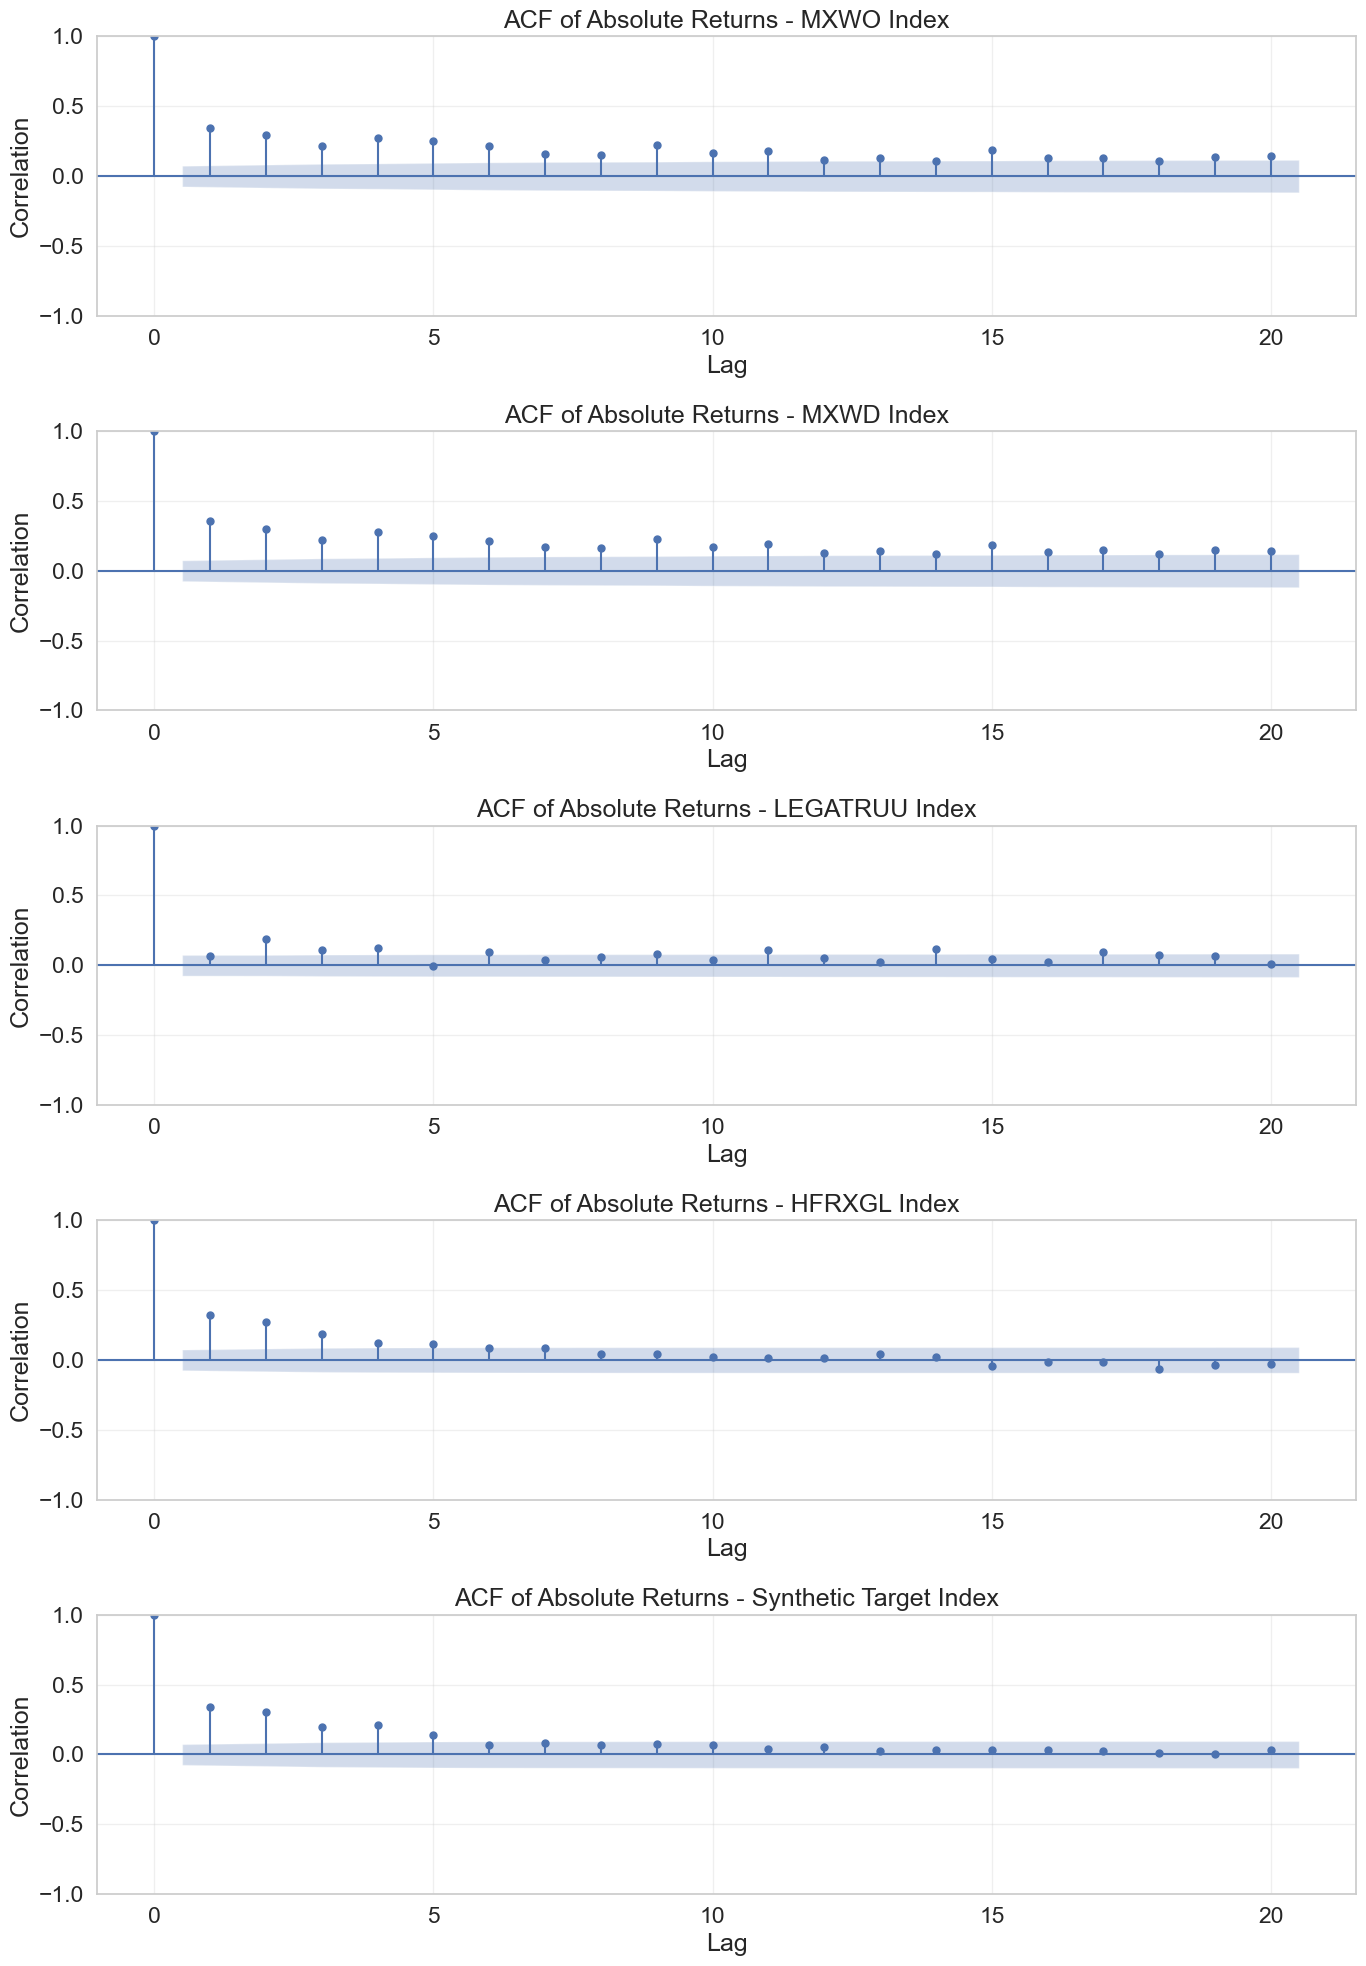

Engle's ARCH LM test (H0: no volatility clustering)
MXWO Index                | LM =  116.856 | p = 0.0000 *** → Volatility clustering present
MXWD Index                | LM =  122.451 | p = 0.0000 *** → Volatility clustering present
LEGATRUU Index            | LM =   39.058 | p = 0.0000 *** → Volatility clustering present
HFRXGL Index              | LM =  127.537 | p = 0.0000 *** → Volatility clustering present
Synthetic Target Index    | LM =  125.252 | p = 0.0000 *** → Volatility clustering present

Significance: *** p<0.001  ** p<0.01  * p<0.05


In [12]:
# Volatility Clustering Analysis 

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch

max_lags = 20

# Costruisco dataset coerente con tutto il notebook
returns_vol = returns_all[target_indices].copy()
returns_vol["Synthetic Target Index"] = target_returns_aligned

returns_vol = returns_vol.dropna()

series_list = returns_vol.columns.tolist()

# ACF of squared returns

fig, axes = plt.subplots(
    len(series_list),
    1,
    figsize=(14, 4 * len(series_list))
)

if len(series_list) == 1:
    axes = [axes]

for i, idx in enumerate(series_list):
    
    squared_returns = returns_vol[idx] ** 2

    plot_acf(
        squared_returns,
        lags=max_lags,
        ax=axes[i],
        alpha=0.05
    )

    axes[i].set_title(f"ACF of Squared Returns - {idx}")
    axes[i].set_xlabel("Lag")
    axes[i].set_ylabel("Correlation")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ACF of absolute returns

fig, axes = plt.subplots(
    len(series_list),
    1,
    figsize=(14, 4 * len(series_list))
)

if len(series_list) == 1:
    axes = [axes]

for i, idx in enumerate(series_list):
    
    abs_returns = returns_vol[idx].abs()

    plot_acf(
        abs_returns,
        lags=max_lags,
        ax=axes[i],
        alpha=0.05
    )

    axes[i].set_title(f"ACF of Absolute Returns - {idx}")
    axes[i].set_xlabel("Lag")
    axes[i].set_ylabel("Correlation")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Engle's ARCH Test

print("Engle's ARCH LM test (H0: no volatility clustering)")
print("=" * 60)

for col in series_list:
    
    r = returns_vol[col].values
    
    lm_stat, lm_pval, _, _ = het_arch(r, nlags=5)

    stars = '***' if lm_pval < 0.001 else \
            '** ' if lm_pval < 0.01  else \
            '*  ' if lm_pval < 0.05  else '   '

    conclusion = "Volatility clustering present" if lm_pval < 0.05 else "No volatility clustering"

    print(f"{col:25s} | LM = {lm_stat:8.3f} | p = {lm_pval:.4f} {stars} → {conclusion}")

print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05")

## 6.0 Target risk profile

In [13]:
# Target risk profile

annual_factor = 52

cum_target = (1 + target_returns_aligned).cumprod()
drawdown = cum_target / cum_target.cummax() - 1

target_stats = pd.DataFrame({
    "Statistic": [
        "Annualized return",
        "Annualized volatility",
        "Sharpe ratio",
        "Max drawdown",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        f"{target_returns_aligned.mean() * annual_factor * 100:.2f}%",
        f"{target_returns_aligned.std() * np.sqrt(annual_factor) * 100:.2f}%",
        f"{(target_returns_aligned.mean() * annual_factor) / (target_returns_aligned.std() * np.sqrt(annual_factor)):.2f}",
        f"{drawdown.min() * 100:.2f}%",
        f"{target_returns_aligned.skew():.2f}",
        f"{target_returns_aligned.kurtosis():.2f}"
    ]
})

print("Synthetic Target Index - risk and performance statistics:")
display(target_stats)

worst_weeks = (
    target_returns_aligned
    .sort_values()
    .head(5)
    .rename("Weekly return")
    .to_frame()
)

worst_weeks.index.name = "Date"
worst_weeks["Weekly return"] = worst_weeks["Weekly return"].map(lambda x: f"{x * 100:.2f}%")

print("5 worst weeks in the Synthetic Target Index history:")
display(worst_weeks)

Synthetic Target Index - risk and performance statistics:


,Statistic,Value
0,Annualized return,1.68%
1,Annualized volatility,5.42%
2,Sharpe ratio,0.31
3,Max drawdown,-27.31%
4,Skewness,-1.80
5,Kurtosis,9.58


5 worst weeks in the Synthetic Target Index history:


,Weekly return
Date,
2020-03-17,-5.73%
2008-10-07,-4.58%
2008-10-14,-4.51%
2020-03-24,-3.28%
2011-08-09,-3.03%


### 6.1 Cumulative performance and drawdown

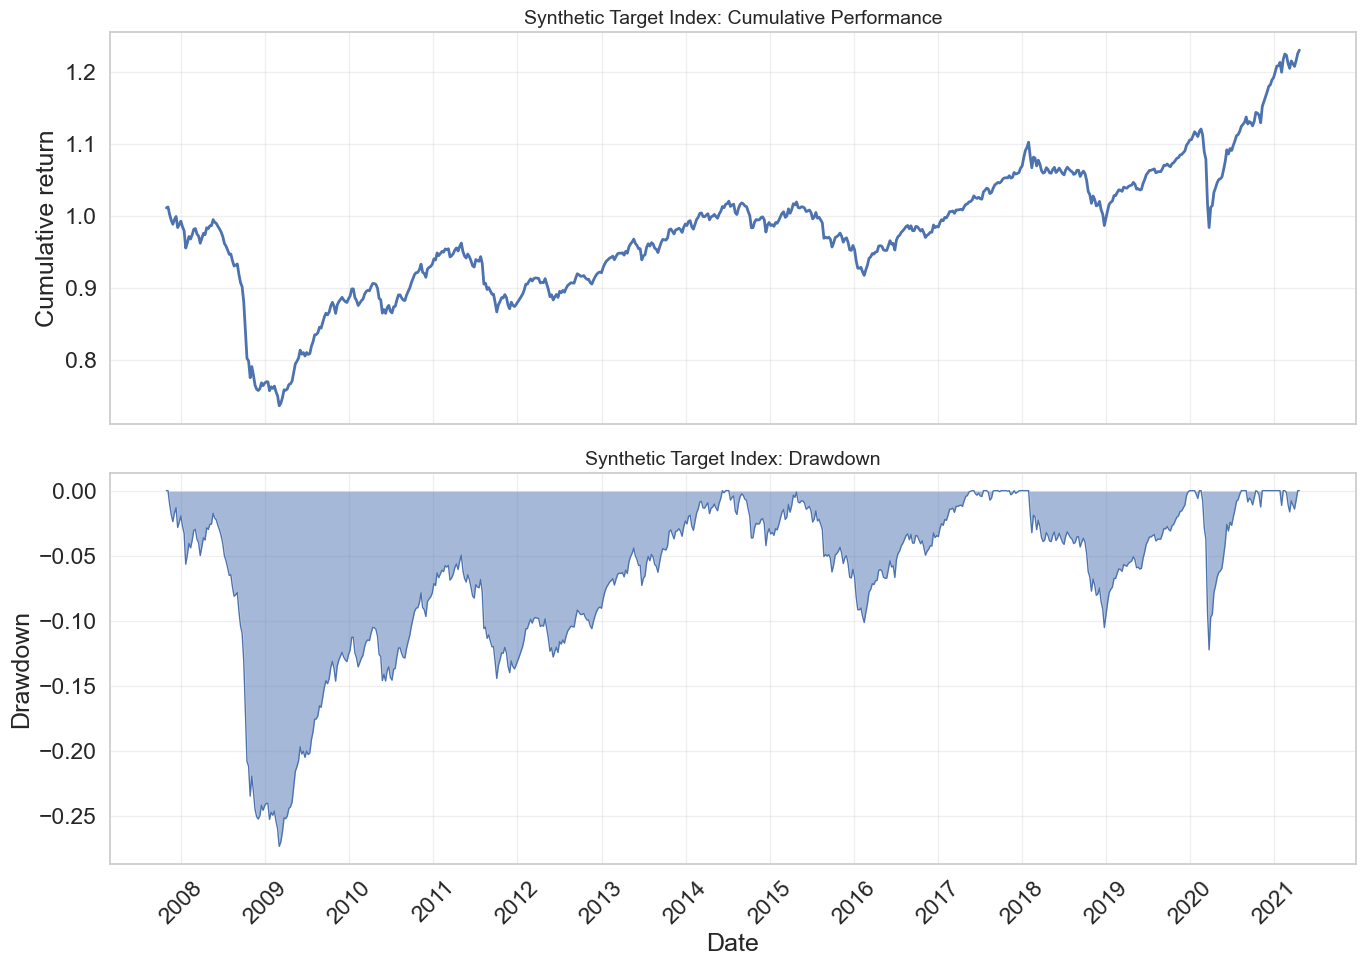

In [14]:
# Cumulative performance and drawdown

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(cum_target, linewidth=2)
ax1.set_title("Synthetic Target Index: Cumulative Performance", fontsize=14)
ax1.set_ylabel("Cumulative return")
ax1.grid(True, alpha=0.3)

ax2.fill_between(drawdown.index, drawdown, 0, alpha=0.5)
ax2.plot(drawdown, linewidth=1)
ax2.set_title("Synthetic Target Index: Drawdown", fontsize=14)
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 6.2 Risk-return profile: target vs futures

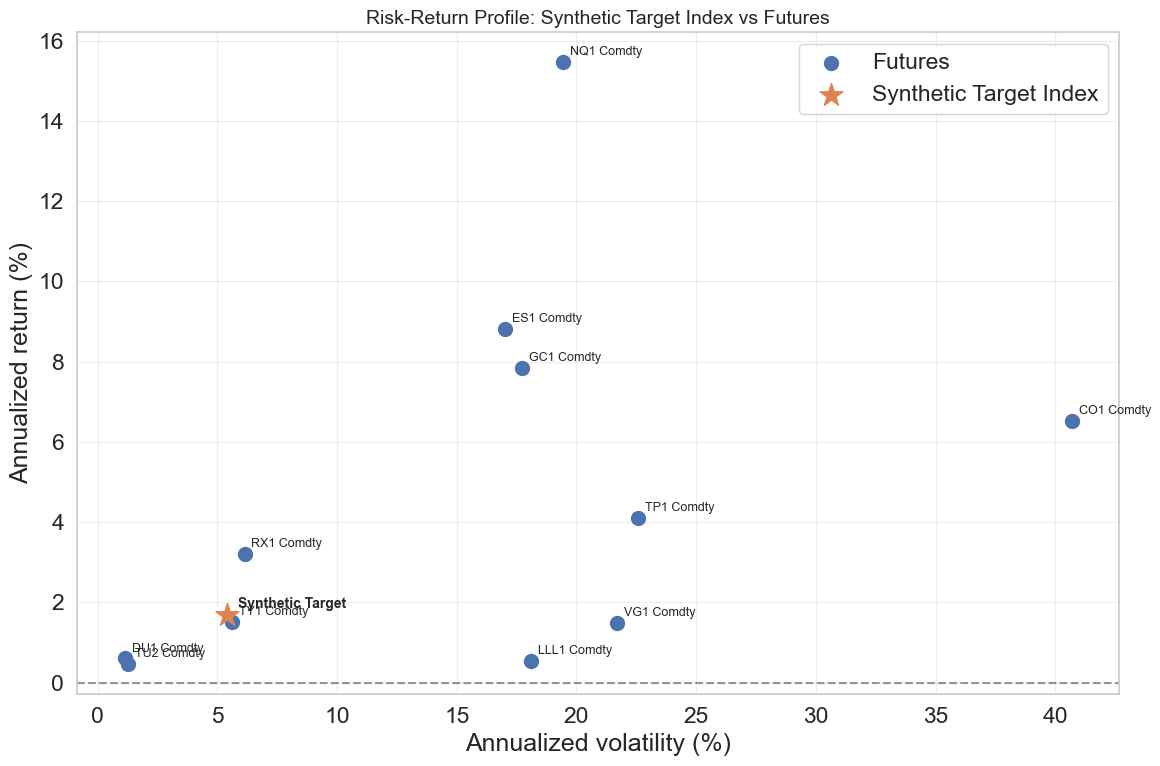

In [15]:
# Risk-return profile: Synthetic Target Index vs futures

ann_ret_fut = futures_returns.mean() * annual_factor
ann_vol_fut = futures_returns.std() * np.sqrt(annual_factor)

target_ret = target_returns_aligned.mean() * annual_factor
target_vol = target_returns_aligned.std() * np.sqrt(annual_factor)

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    ann_vol_fut * 100,
    ann_ret_fut * 100,
    s=100,
    label="Futures"
)

for col in futures_returns.columns:
    ax.annotate(
        col,
        xy=(ann_vol_fut[col] * 100, ann_ret_fut[col] * 100),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.scatter(
    target_vol * 100,
    target_ret * 100,
    s=300,
    marker="*",
    label="Synthetic Target Index",
    zorder=4
)

ax.annotate(
    "Synthetic Target",
    xy=(target_vol * 100, target_ret * 100),
    xytext=(8, 5),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

ax.axhline(0, color="black", linestyle="--", alpha=0.4)
ax.set_title("Risk-Return Profile: Synthetic Target Index vs Futures", fontsize=14)
ax.set_xlabel("Annualized volatility (%)")
ax.set_ylabel("Annualized return (%)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### 6.3 Rolling relationship between target and futures

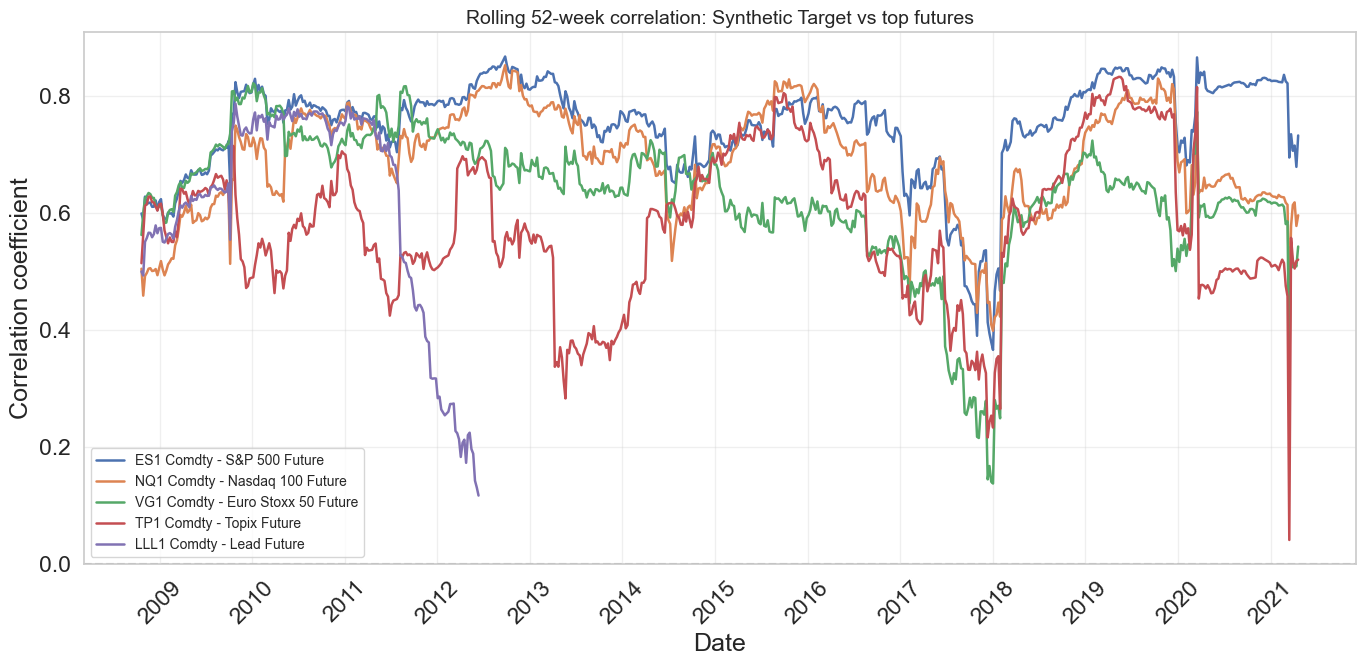

In [16]:
# Rolling relationship between Synthetic Target Index and top futures

rolling_window = 52

# Use top 5 for rolling analysis, without changing the previous top 3 used for QQ/scatter
top5_futures = correlations.index[:5].tolist()

fig, ax = plt.subplots(figsize=(14, 7))

for fut in top5_futures:
    rolling_corr = target_returns_aligned.rolling(rolling_window).corr(futures_returns[fut])
    ax.plot(
        rolling_corr,
        linewidth=1.8,
        label=f"{fut} - {variable_info.get(fut, fut)}"
    )

ax.axhline(0, color="black", linestyle="--", alpha=0.4)
ax.set_title(f"Rolling {rolling_window}-week correlation: Synthetic Target vs top futures", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Correlation coefficient")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 6.4 Rolling beta

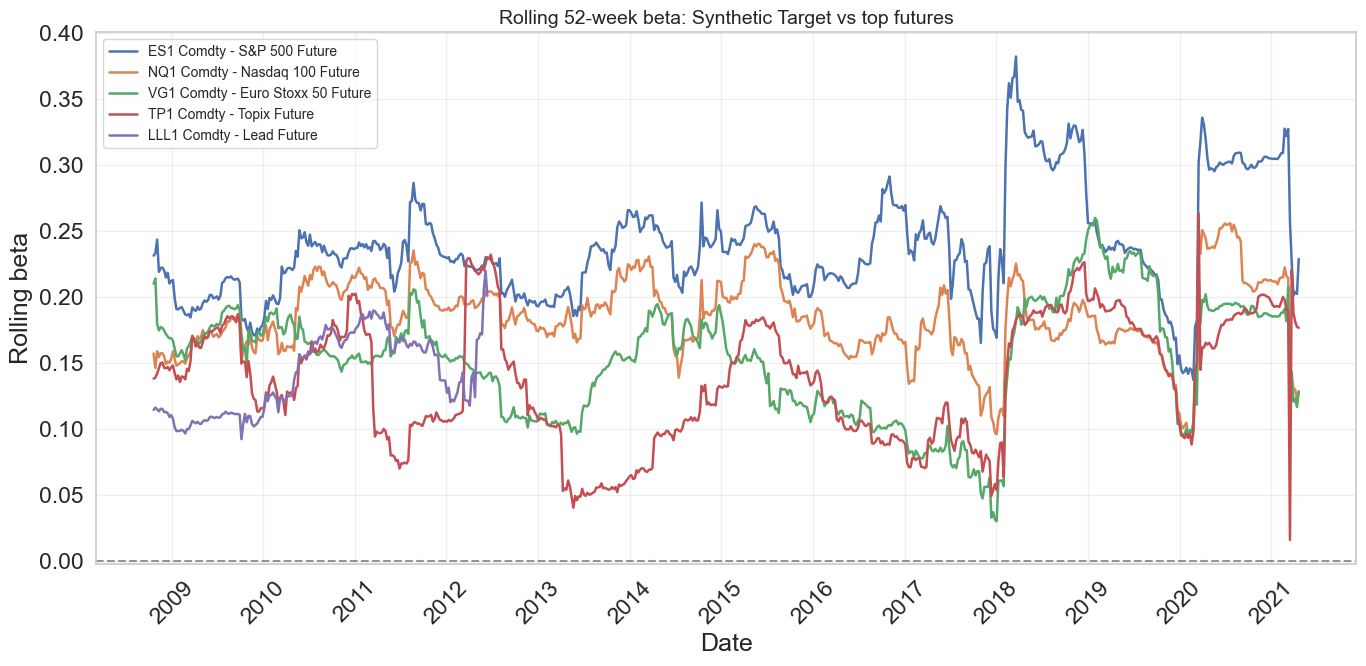

In [17]:
# Rolling beta: Synthetic Target vs top futures

fig, ax = plt.subplots(figsize=(14, 7))

for fut in top5_futures:
    rolling_cov = target_returns_aligned.rolling(rolling_window).cov(futures_returns[fut])
    rolling_var = futures_returns[fut].rolling(rolling_window).var()
    rolling_beta = rolling_cov / rolling_var

    ax.plot(
        rolling_beta,
        linewidth=1.8,
        label=f"{fut} - {variable_info.get(fut, fut)}"
    )

ax.axhline(0, color="black", linestyle="--", alpha=0.4)
ax.set_title(f"Rolling {rolling_window}-week beta: Synthetic Target vs top futures", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Rolling beta")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 6.5 Rolling tracking error using single futures

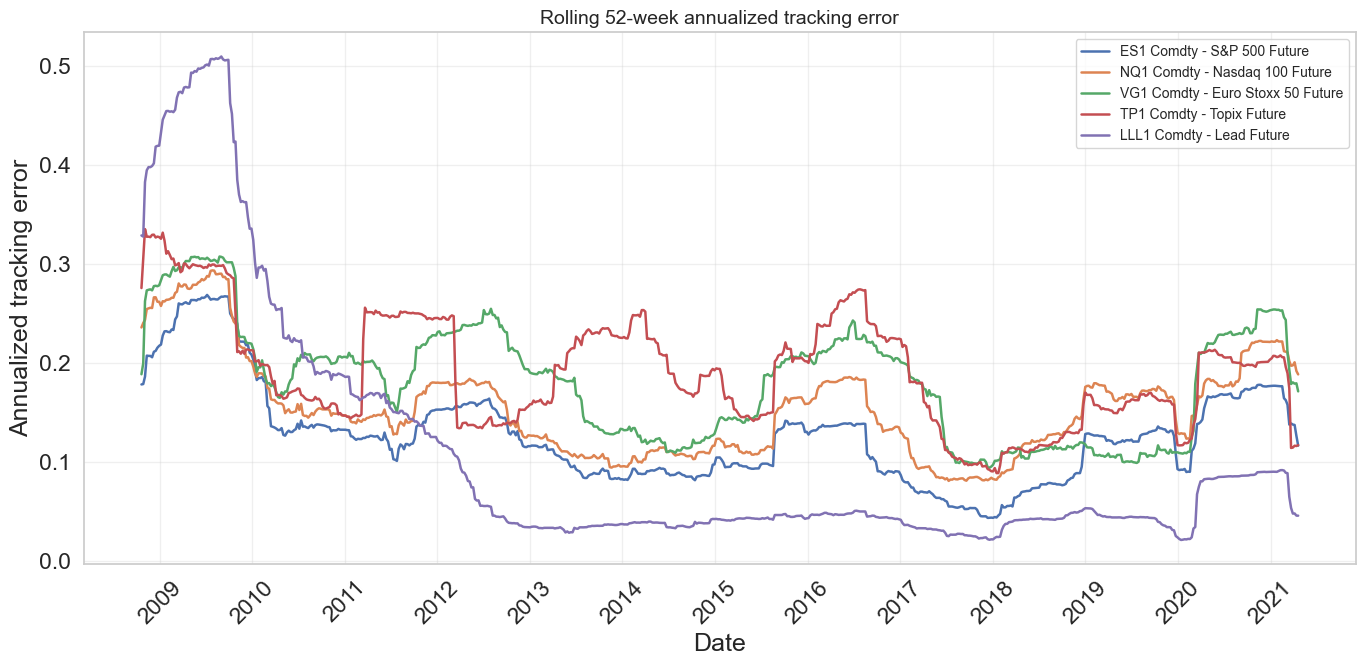

In [18]:
# Rolling tracking error using single futures

rolling_te = pd.DataFrame(index=target_returns_aligned.index)

for fut in top5_futures:
    diff = target_returns_aligned - futures_returns[fut]
    rolling_te[fut] = diff.rolling(rolling_window).std() * np.sqrt(annual_factor)

fig, ax = plt.subplots(figsize=(14, 7))

for fut in top5_futures:
    ax.plot(
        rolling_te[fut],
        linewidth=1.8,
        label=f"{fut} - {variable_info.get(fut, fut)}"
    )

ax.set_title(f"Rolling {rolling_window}-week annualized tracking error", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Annualized tracking error")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

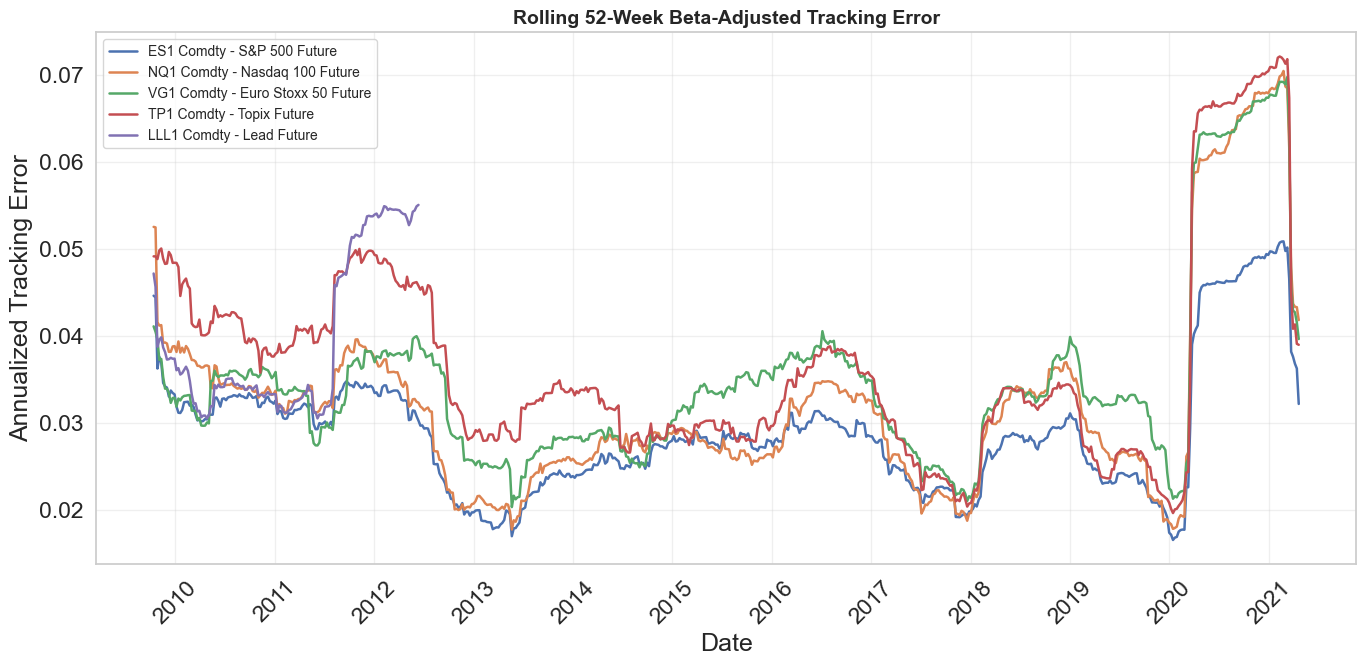

In [19]:
# Beta-adjusted rolling tracking error using single futures
# This corrects the simple single-future tracking error by scaling each future
# according to its rolling beta with respect to the target.

rolling_te_beta_adjusted = pd.DataFrame(index=target_returns_aligned.index)
rolling_beta_for_te = pd.DataFrame(index=target_returns_aligned.index)

for fut in top5_futures:
    # Rolling beta: Cov(target, future) / Var(future)
    rolling_cov = target_returns_aligned.rolling(rolling_window).cov(futures_returns[fut])
    rolling_var = futures_returns[fut].rolling(rolling_window).var()
    rolling_beta = rolling_cov / rolling_var

    rolling_beta_for_te[fut] = rolling_beta

    # Single-factor beta-adjusted replica
    beta_adjusted_replica = rolling_beta * futures_returns[fut]

    # Beta-adjusted tracking error
    diff_beta_adjusted = target_returns_aligned - beta_adjusted_replica

    rolling_te_beta_adjusted[fut] = (
        diff_beta_adjusted.rolling(rolling_window).std() * np.sqrt(annual_factor)
    )

# Plot beta-adjusted rolling tracking error
fig, ax = plt.subplots(figsize=(14, 7))

for fut in top5_futures:
    ax.plot(
        rolling_te_beta_adjusted[fut],
        linewidth=1.8,
        label=f"{fut} - {variable_info.get(fut, fut)}"
    )

ax.set_title(
    f"Rolling {rolling_window}-Week Beta-Adjusted Tracking Error",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Tracking Error")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 6.6 Rolling summary table

In [20]:
# Rolling relationship summary table

summary_rows = []

for fut in top5_futures:
    rolling_corr = target_returns_aligned.rolling(rolling_window).corr(futures_returns[fut])

    rolling_cov = target_returns_aligned.rolling(rolling_window).cov(futures_returns[fut])
    rolling_var = futures_returns[fut].rolling(rolling_window).var()
    rolling_beta = rolling_cov / rolling_var

    diff = target_returns_aligned - futures_returns[fut]
    rolling_tracking_error = diff.rolling(rolling_window).std() * np.sqrt(annual_factor)

    summary_rows.append({
        "Future": fut,
        "Instrument": variable_info.get(fut, fut),
        "Full-sample correlation": target_returns_aligned.corr(futures_returns[fut]),
        "Average rolling correlation": rolling_corr.mean(),
        "Correlation volatility": rolling_corr.std(),
        "Avg rolling beta": rolling_beta.mean(),
        "Avg rolling TE": rolling_tracking_error.mean(),
        "Avg Beta-Adjusted Rolling TE": rolling_te_beta_adjusted[fut].mean()
    })

rolling_summary = pd.DataFrame(summary_rows).set_index("Future")
rolling_summary = rolling_summary.sort_values("Avg rolling TE")

print("Rolling relationship summary:")
display(rolling_summary.round(4))

Rolling relationship summary:


,Instrument,Full-sample correlation,Average rolling correlation,Correlation volatility,Avg rolling beta,Avg rolling TE,Avg Beta-Adjusted Rolling TE
Future,,,,,,,
LLL1 Comdty,Lead Future,0.4247,0.6080,0.1840,0.1406,0.1083,0.0399
ES1 Comdty,S&P 500 Future,0.7437,0.7500,0.0830,0.2378,0.1264,0.0290
NQ1 Comdty,Nasdaq 100 Future,0.6626,0.6891,0.0908,0.1847,0.1539,0.0324
VG1 Comdty,Euro Stoxx 50 Future,0.6374,0.6318,0.1113,0.1531,0.1806,0.0347
TP1 Comdty,Topix Future,0.5666,0.5795,0.1252,0.1367,0.1906,0.0368


### 6.7 Multicollinearity check: VIF

In [21]:
# Variance Inflation Factor on futures returns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = futures_returns.dropna()
X_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_const.values, i + 1)
        for i in range(X_vif.shape[1])
    ]
})

vif_data["Instrument"] = vif_data["Feature"].map(variable_info)
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
vif_data["VIF"] = vif_data["VIF"].round(2)

print("Variance Inflation Factor - Futures Returns:")
display(vif_data[["Feature", "Instrument", "VIF"]])

Variance Inflation Factor - Futures Returns:


,Feature,Instrument,VIF
0,ES1 Comdty,S&P 500 Future,8.97
1,NQ1 Comdty,Nasdaq 100 Future,6.16
2,VG1 Comdty,Euro Stoxx 50 Future,2.91
3,TY1 Comdty,US 10yr Note Future,2.75
4,RX1 Comdty,Euro-Bund Future,2.40
5,TU2 Comdty,US 2yr Note Future,2.23
6,DU1 Comdty,Euro-Schatz Future,2.07
7,TP1 Comdty,Topix Future,1.70
8,LLL1 Comdty,Lead Future,1.57
9,CO1 Comdty,Brent Crude Future,1.39


### 6.8 PCA on futures returns

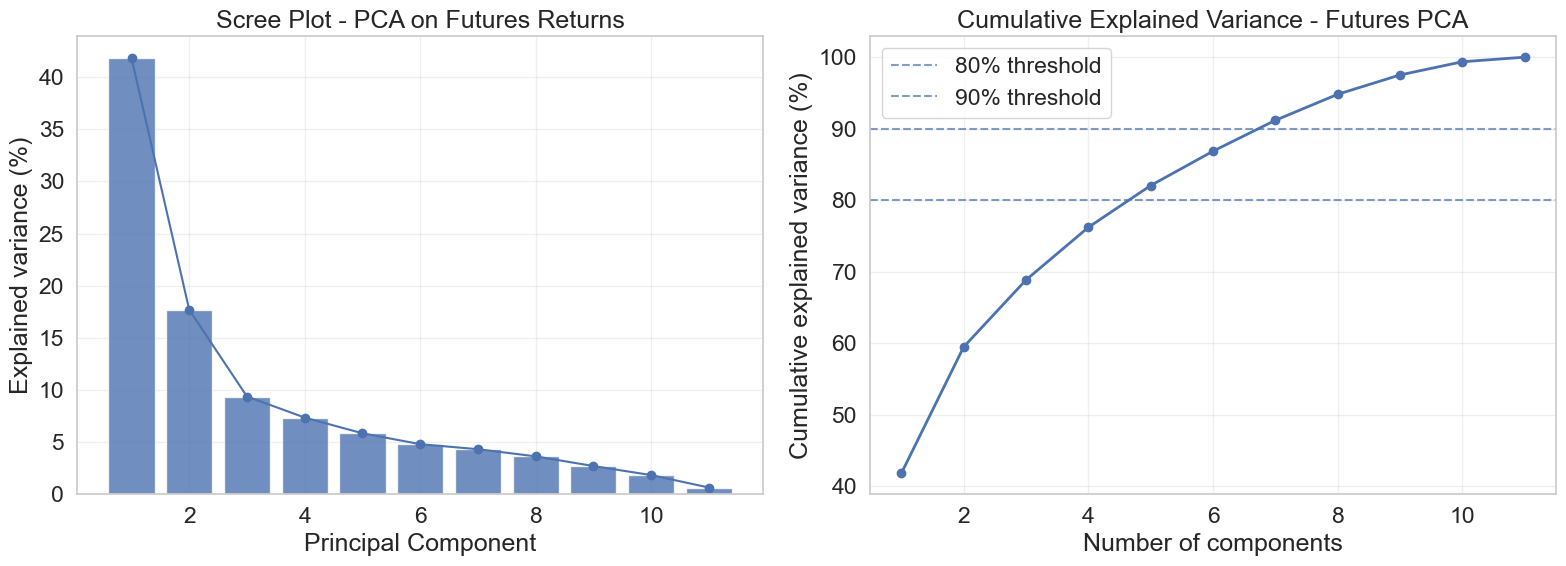

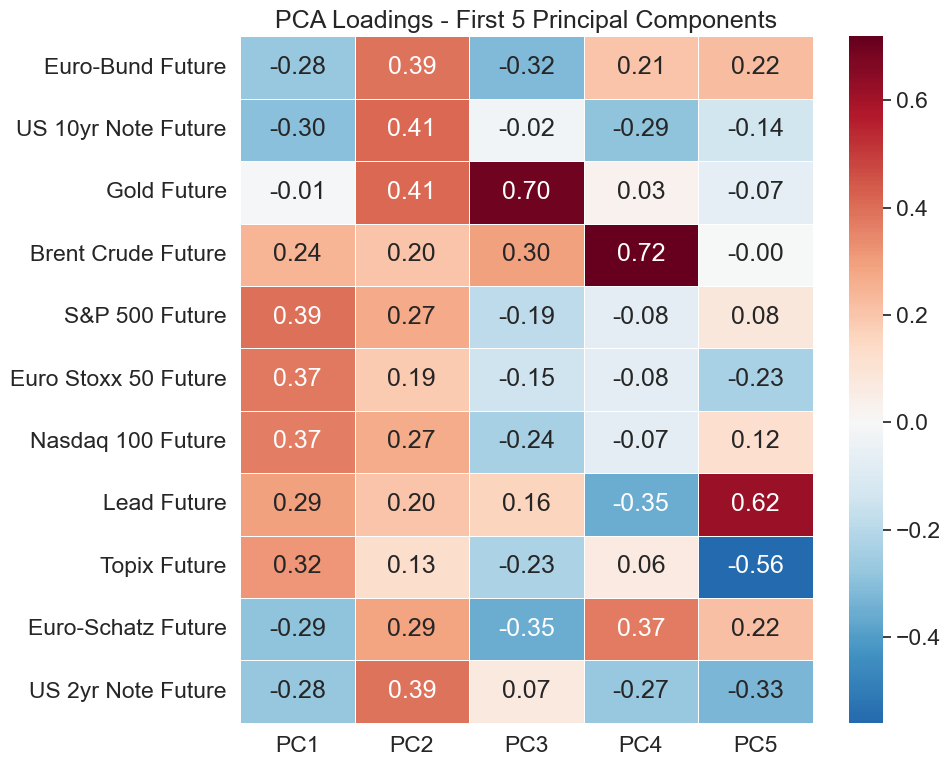

PCs needed to explain >= 80% of variance: 5
PCs needed to explain >= 90% of variance: 7
Variance explained by first 3 PCs      : 68.9%


In [22]:
from sklearn.preprocessing import StandardScaler

X_pca = futures_returns.dropna()
X_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(range(1, len(explained) + 1), explained * 100, alpha=0.8)
ax1.plot(range(1, len(explained) + 1), explained * 100, "o-", linewidth=1.5)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained variance (%)")
ax1.set_title("Scree Plot - PCA on Futures Returns")
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", linewidth=2)
ax2.axhline(80, linestyle="--", alpha=0.7, label="80% threshold")
ax2.axhline(90, linestyle="--", alpha=0.7, label="90% threshold")
ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative explained variance (%)")
ax2.set_title("Cumulative Explained Variance - Futures PCA")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca.components_[:5].T,
    index=[variable_info.get(c, c) for c in futures_returns.columns],
    columns=[f"PC{i+1}" for i in range(5)]
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    loadings,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("PCA Loadings - First 5 Principal Components")
plt.tight_layout()
plt.show()

n_80 = np.searchsorted(cumulative, 0.80) + 1
n_90 = np.searchsorted(cumulative, 0.90) + 1

print(f"PCs needed to explain >= 80% of variance: {n_80}")
print(f"PCs needed to explain >= 90% of variance: {n_90}")
print(f"Variance explained by first 3 PCs      : {cumulative[2] * 100:.1f}%")